# Class Engineering — Behavioural Labelling EDA (pooled multi-month cohort)

Self-derived 4-class label anchored on **each user's own expiry date `E`**.

1. **Engagement is total seconds listened** in the 30 days around `E`. The movement label compares **total post-renewal volume to total pre-renewal volume** (`vol_ratio = post_total_secs / pre_total_secs`) — one intuitive "did they listen more or less overall" quantity, not a per-active-day intensity.
2. **Minimum-evidence filter on the pre window only**: a user needs `pre_n_days ≥ 7` for a credible baseline before any movement label. There is **no post-window gate** — the volume ratio has no post denominator, so a renewer who listened on only a few days (or not at all) is still labelled, not discarded.
3. **Zero post-volume is the clearest contraction**: a renewer with `post_total_secs = 0` (paid, then never listened for 30 days) is labelled CONTRACTION rather than dropped.

### Label rule
```
Let vol_ratio = post_total_secs / pre_total_secs   (NaN if pre_total_secs == 0)

if pre_n_days < 7:           INSUFFICIENT_DATA   (no credible pre-baseline)
elif not renewed:            CHURN
elif post_total_secs == 0:   CONTRACTION         (renewed but never listened)
elif vol_ratio is NaN:       INSUFFICIENT_DATA   (no pre-volume to compare)
elif vol_ratio < 0.50:       CONTRACTION         (post volume below half of pre)
elif vol_ratio > 1.50:       EXPANSION           (post volume above 1.5x pre)
else:                        STABLE
```
The 0.50 / 1.50 band is calibrated so STABLE ≈ 60% of the core cohort (threshold sweep in §8).

### Cohort
One row per `(msno, E)` expiry event whose `membership_expire_date` is in the pooled window. Users can appear in multiple months. Pre/post log windows are symmetric ±30 days around each user's own `E`.

### Data boundaries
* `user_logs.csv`: 2015-01-01 → 2017-02-28.
* `user_logs_v2.csv`: 2017-03-01 → 2017-03-31 (extends post window for late expiries).
* Default cohort window: **2016-08-01 → 2017-01-31** (six expiry months). Configurable.

No classification in this notebook — dataset building and exploratory views only.

In [ ]:
from __future__ import annotations
from pathlib import Path
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA  = Path('KKBoxData/RawData')   # parquet copies of the raw KKBox files
OUT   = Path('KKBoxData')           # engineered output drops here
PLOTS = Path('FinalPlots'); PLOTS.mkdir(exist_ok=True)
SEED = 42

COHORT_START = pd.Timestamp('2016-08-01')
COHORT_END   = pd.Timestamp('2017-01-31')
WINDOW_DAYS  = 30
GRACE_DAYS   = 30
MIN_DAYS     = 7
# Movement band on the TOTAL-volume ratio (post_total_secs / pre_total_secs):
# CONTRACTION if ratio < 0.50 (post volume below half of pre), EXPANSION if ratio > 1.50
# (post volume above 1.5x pre), else STABLE. The band edges are STABLE (inclusive).
# Calibrated so STABLE is ~60% of the core cohort (threshold sweep in section 8).
VOL_LOW, VOL_HIGH = 0.50, 1.50

# --- Modelling hand-off config (consumed by the separate classification notebooks) ---
HORIZONS        = [1, 7, 14, 30, 60]   # days before expiry E for the time-before-renewal experiment
OBS_LEN         = 30                    # sliding observation-window length (days) for horizon features
SEQ_WINDOW_DAYS = 60                    # daily-sequence length exported for the GRU/LSTM model
N_FOLDS         = 5                     # user-grouped cross-validation folds
HOLDOUT_FRAC    = 0.15                  # fraction of users reserved for the canonical user-grouped holdout

CLASS_ORDER = ['CHURN', 'CONTRACTION', 'STABLE', 'EXPANSION', 'INSUFFICIENT_DATA']
PALETTE = {
    'CHURN':             '#d62728',
    'CONTRACTION':       '#ff7f0e',
    'STABLE':            '#7f7f7f',
    'EXPANSION':         '#2ca02c',
    'INSUFFICIENT_DATA': '#cccccc',
}

def save_fig(name):
    plt.savefig(PLOTS / f'{name}.png', dpi=150, bbox_inches='tight')

print(f'Cohort expiry window: {COHORT_START.date()} → {COHORT_END.date()}')
sns.set_style('whitegrid')

Cohort expiry window: 2016-08-01 → 2017-01-31


## 1. Cohort — one row per `(msno, E)` expiry event

In [2]:
import pyarrow.parquet as pq

TXN_COLS = ['msno', 'transaction_date', 'membership_expire_date',
            'actual_amount_paid', 'plan_list_price', 'is_cancel', 'is_auto_renew',
            'payment_plan_days', 'payment_method_id']
txn1 = pq.read_table(DATA / 'transactions.parquet',    columns=TXN_COLS).to_pandas()
txn2 = pq.read_table(DATA / 'transactions_v2.parquet', columns=TXN_COLS).to_pandas()
txn = pd.concat([txn1, txn2], ignore_index=True).drop_duplicates()
for c in ['transaction_date', 'membership_expire_date']:
    txn[c] = pd.to_datetime(txn[c], format='%Y%m%d')
del txn1, txn2; gc.collect()
print(f'transactions rows (concat + dedup): {len(txn):,}')

in_window = txn['membership_expire_date'].between(COHORT_START, COHORT_END)
# Leakage guard: the event-defining transaction must be KNOWN AT E. Backdated
# cancellations can post a transaction_date AFTER the expiry date they carry, which
# would otherwise win .tail(1) and leak post-E info through is_cancel / pre_* features.
known_at_E = txn['transaction_date'] <= txn['membership_expire_date']
events = (txn[in_window & known_at_E]
          .sort_values(['msno', 'membership_expire_date', 'transaction_date'])
          .groupby(['msno', 'membership_expire_date'], as_index=False)
          .tail(1)
          .rename(columns={'membership_expire_date': 'E',
                           'transaction_date':       'last_pre_txn_date',
                           'plan_list_price':        'pre_list_price',
                           'actual_amount_paid':     'pre_amount_paid'}))
events['expiry_month'] = events['E'].dt.to_period('M').astype(str)
print(f'Expiry events: {len(events):,}   unique users: {events["msno"].nunique():,}')
events.groupby('expiry_month').size().rename('events').to_frame()

transactions rows (concat + dedup): 22,975,416
Expiry events: 6,133,147   unique users: 1,507,727


,events
expiry_month,
2016-08,888706
2016-09,1026214
2016-10,1015421
2016-11,1151110
2016-12,1030759
2017-01,1020937


## 2. Renewal decision — forward grace window **and** pre-`E` early renewals

A member is **renewed** (not churned) at `E` if *either*:

1. **Forward renewal** — a paid, non-cancel transaction (`actual_amount_paid > 0`,
   `is_cancel = 0`) posts in the grace window `[E, E + 30]`; or
2. **Pre-`E` early renewal** — a non-cancel transaction dated on/before `E` already
   pushes `membership_expire_date` **beyond `E`**, so coverage is still active at `E`
   (the member renewed early). This counts **only when it extends the expiry further
   than `E` itself** — i.e. `membership_expire_date > E`.

Condition 2 aligns our label with the official KKBox *effective-expiry* logic
(validated in §9e) and removes the ~42 % of churn events that were merely
superseded intermediate expiries a member had already renewed past.


In [3]:
events['grace_end'] = events['E'] + pd.Timedelta(days=GRACE_DAYS)

# --- (1) Forward renewal: paid, non-cancel transaction in [E, E + grace] ---
renew_cand = txn.merge(events[['msno', 'E', 'grace_end']], on='msno', how='inner')
renew_cand = renew_cand[(renew_cand['transaction_date'] >= renew_cand['E']) &
                         (renew_cand['transaction_date'] <= renew_cand['grace_end'])].copy()
renew_cand['is_paid_renewal'] = ((renew_cand['actual_amount_paid'] > 0) &
                                  (renew_cand['is_cancel'] == 0)).astype(int)
renew_cand = renew_cand.sort_values(['msno', 'E', 'transaction_date'])
paid = renew_cand[renew_cand['is_paid_renewal'] == 1]
first_paid = (paid.groupby(['msno', 'E'], as_index=False).head(1)
              [['msno', 'E', 'transaction_date', 'plan_list_price', 'actual_amount_paid']]
              .rename(columns={'transaction_date': 'first_renewal_date',
                               'plan_list_price':  'post_list_price',
                               'actual_amount_paid': 'post_amount_paid'}))
renew_agg = renew_cand.groupby(['msno', 'E']).agg(
    n_grace_txns=('is_paid_renewal', 'size'),
    renewed_forward=('is_paid_renewal', 'max'),
).reset_index()
events = (events.merge(renew_agg, on=['msno', 'E'], how='left')
                 .merge(first_paid, on=['msno', 'E'], how='left'))
events['renewed_forward'] = events['renewed_forward'].fillna(0).astype(int)
events['n_grace_txns']    = events['n_grace_txns'].fillna(0).astype(int)

# --- (2) Pre-E early renewal: a non-cancel txn on/before E that pushes expiry PAST E ---
# Only counts when it extends membership further than the current expiry (expire > E),
# matching the official KKBox effective-expiry rule (see section 9e).
preE = txn.loc[(txn['is_cancel'] == 0) &
               (txn['membership_expire_date'] > COHORT_START) &
               (txn['transaction_date'] <= COHORT_END),
               ['msno', 'transaction_date', 'membership_expire_date']]
preE = preE.merge(events[['msno', 'E']], on='msno', how='inner')
preE = preE[(preE['transaction_date'] <= preE['E']) &
            (preE['membership_expire_date'] > preE['E'])]
preE_cov = preE.groupby(['msno', 'E'])['membership_expire_date'].max().rename('preE_cov_end')
events = events.merge(preE_cov, on=['msno', 'E'], how='left')
events['renewed_preE'] = events['preE_cov_end'].notna().astype(int)

# --- Final renewal decision: forward paid renewal OR early renewal extending past E ---
events['renewed'] = ((events['renewed_forward'] == 1) | (events['renewed_preE'] == 1)).astype(int)

print(f"Forward paid renewal rate : {events['renewed_forward'].mean():.3%}")
print(f"Pre-E early-renewal rate  : {events['renewed_preE'].mean():.3%}")
print(f"Overall renewal rate      : {events['renewed'].mean():.3%}  "
      f"(pre-E adds {(events['renewed'] & ~events['renewed_forward'].astype(bool)).mean():.3%})")

# keep the pipeline schema clean — drop the helper columns once `renewed` is set
events = events.drop(columns=['renewed_forward', 'renewed_preE', 'preE_cov_end'])
del renew_cand, paid, first_paid, renew_agg, preE, preE_cov; gc.collect()


Forward paid renewal rate : 88.379%
Pre-E early-renewal rate  : 74.557%
Overall renewal rate      : 91.394%  (pre-E adds 3.015%)


29

## 3. Pre/Post listening — single chunked scan across both log files

In [4]:
import pyarrow.parquet as pq

pre_start = (events['E'] - pd.Timedelta(days=WINDOW_DAYS)).min()
post_end  = (events['E'] + pd.Timedelta(days=WINDOW_DAYS)).max()
print(f'Log window: {pre_start.date()} → {post_end.date()}')

cohort_users = set(events['msno'])
USECOLS = ['msno', 'date', 'total_secs']
log_chunks = []
for src in ['user_logs.parquet', 'user_logs_v2.parquet']:
    p = DATA / src
    if not p.exists():
        continue
    pf = pq.ParquetFile(p)
    for batch in pf.iter_batches(batch_size=2_000_000, columns=USECOLS):
        ch = batch.to_pandas()
        ch = ch[ch['msno'].isin(cohort_users)]
        if ch.empty:
            continue
        ch['total_secs'] = ch['total_secs'].clip(lower=0, upper=86_400)   # sanitise corrupt negatives / >1-day values
        ch['date'] = pd.to_datetime(ch['date'], format='%Y%m%d')
        ch = ch[(ch['date'] >= pre_start) & (ch['date'] <= post_end)]
        if not ch.empty:
            log_chunks.append(ch)
logs = pd.concat(log_chunks, ignore_index=True) if log_chunks else pd.DataFrame(columns=USECOLS)
del log_chunks; gc.collect()
print(f'Filtered log rows: {len(logs):,}')

logs = logs.merge(events[['msno', 'E']], on='msno', how='inner')
logs['offset'] = (logs['date'] - logs['E']).dt.days
pre  = logs[(logs['offset'] >= -WINDOW_DAYS) & (logs['offset'] <= -1)]
post = logs[(logs['offset'] >=  1)           & (logs['offset'] <=  WINDOW_DAYS)]
pre_agg  = pre.groupby(['msno', 'E']).agg(
    pre_total_secs=('total_secs', 'sum'), pre_n_days=('date', 'nunique')).reset_index()
post_agg = post.groupby(['msno', 'E']).agg(
    post_total_secs=('total_secs', 'sum'), post_n_days=('date', 'nunique')).reset_index()
del logs, pre, post; gc.collect()

events = events.merge(pre_agg, on=['msno', 'E'], how='left').merge(post_agg, on=['msno', 'E'], how='left')
for c in ['pre_total_secs', 'post_total_secs', 'pre_n_days', 'post_n_days']:
    events[c] = events[c].fillna(0)

events['pre_rate']  = np.where(events['pre_n_days']  > 0, events['pre_total_secs']  / events['pre_n_days'],  np.nan)
events['post_rate'] = np.where(events['post_n_days'] > 0, events['post_total_secs'] / events['post_n_days'], np.nan)
# Label metric: ratio of TOTAL seconds listened post- vs pre-renewal (volume, not per-active-day intensity)
events['vol_ratio'] = np.where(events['pre_total_secs'] > 0,
                               events['post_total_secs'] / events['pre_total_secs'], np.nan)
print(events[['pre_n_days', 'post_n_days', 'pre_rate', 'post_rate', 'vol_ratio']].describe().round(2))

Log window: 2016-07-02 → 2017-03-02
Filtered log rows: 121,551,145
       pre_n_days  post_n_days    pre_rate   post_rate   vol_ratio
count  6133147.00   6133147.00  4717446.00  4474895.00  4717446.00
mean        13.15        12.35     6443.11     6428.34        6.51
std         11.01        11.05     6157.86     6186.26     2507.18
min          0.00         0.00        0.00        0.00        0.00
25%          1.00         0.00     2840.47     2829.63        0.51
50%         13.00        11.00     4764.54     4769.73        0.90
75%         24.00        23.00     7821.63     7807.86        1.36
max         30.00        30.00    86400.00    86400.00  3549847.73


## 4. Apply the label rule

In [ ]:
def assign_label(r):
    if r['pre_n_days'] < MIN_DAYS:
        return 'INSUFFICIENT_DATA'           # no credible pre-baseline
    if r['renewed'] == 0:
        return 'CHURN'
    if r['post_total_secs'] == 0:
        return 'CONTRACTION'                 # renewed but zero total seconds in 30d post = clearest disengagement
    if np.isnan(r['vol_ratio']):
        return 'INSUFFICIENT_DATA'           # no pre-volume to form a ratio
    if r['vol_ratio'] < VOL_LOW:
        return 'CONTRACTION'                 # total post volume < half of pre
    if r['vol_ratio'] > VOL_HIGH:
        return 'EXPANSION'                   # total post volume > 1.5x pre
    return 'STABLE'

events['label'] = events.apply(assign_label, axis=1)
events['is_silent_renewer'] = ((events['renewed'] == 1) & (events['post_total_secs'] == 0)).astype(int)
events['has_pre_evidence']  = (events['pre_n_days']  >= MIN_DAYS).astype(int)
events['has_post_evidence'] = (events['post_n_days'] >= MIN_DAYS).astype(int)
events['has_evidence']      = events['has_pre_evidence'] * events['has_post_evidence']
events['post_observed_but_silent'] = ((events['post_n_days'] >= MIN_DAYS) & (events['post_total_secs'] == 0)).astype(int)
print(events['label'].value_counts())

print(f"\nSilent renewers (renewed, 0 post seconds): {events['is_silent_renewer'].sum():,}")
print(f"Core cohort (label != INSUFFICIENT_DATA): {(events['label'] != 'INSUFFICIENT_DATA').sum():,}")

label
STABLE               2387693
INSUFFICIENT_DATA    2348647
EXPANSION             654405
CONTRACTION           581867
CHURN                 160535
Name: count, dtype: int64

Silent renewers (renewed, 0 post seconds): 1,257,833
Core cohort (label != INSUFFICIENT_DATA): 3,784,500


## 5. Class distribution — all events vs core cohort

Total events: 6,133,147   Core: 3,784,500 (61.7%)
                   all_events_%  core_events_%
label                                         
CHURN                      2.62           4.24
CONTRACTION                9.49          15.38
STABLE                    38.93          63.09
EXPANSION                 10.67          17.29
INSUFFICIENT_DATA         38.29           0.00


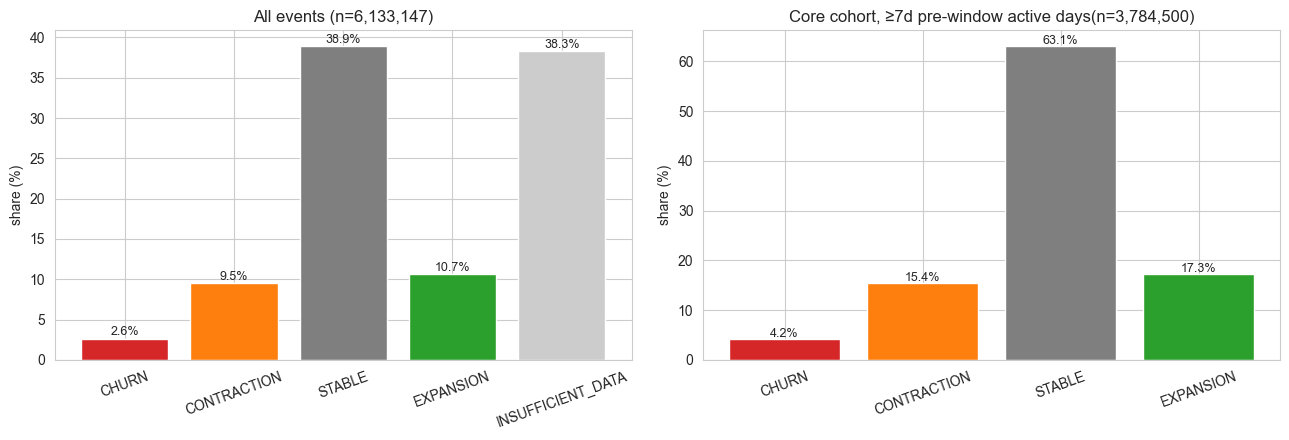

In [6]:
all_dist  = events['label'].value_counts(normalize=True).reindex(CLASS_ORDER).fillna(0)
core_mask = events['label'] != 'INSUFFICIENT_DATA'
core_dist = events.loc[core_mask, 'label'].value_counts(normalize=True).reindex(CLASS_ORDER).fillna(0)
print(f'Total events: {len(events):,}   Core: {core_mask.sum():,} ({core_mask.mean():.1%})')
summary = pd.DataFrame({'all_events_%': (all_dist*100).round(2),
                         'core_events_%': (core_dist*100).round(2)})
print(summary)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, ser, title in zip(ax, [all_dist, core_dist],
                          [f'All events (n={len(events):,})',
                           f'Core cohort (≥{MIN_DAYS}d active before window, n={core_mask.sum():,})']):
    s = ser[ser > 0]
    a.bar(s.index, s.values * 100, color=[PALETTE[c] for c in s.index])
    a.set_ylabel('share (%)'); a.set_title(title)
    for i, v in enumerate(s.values * 100):
        a.text(i, v + 0.4, f'{v:.1f}%', ha='center', fontsize=9)
    plt.setp(a.get_xticklabels(), rotation=20)
plt.tight_layout(); save_fig('05_class_distribution_all_vs_core'); plt.show()

## 6. Renewals & class composition per expiry month

  expiry_month   events  renewal_rate  mean_pre_rate  mean_post_rate  \
0      2016-08   888706         0.950       6353.847        6309.358   
1      2016-09  1026214         0.907       6372.398        6361.590   
2      2016-10  1015421         0.933       6436.856        6512.110   
3      2016-11  1151110         0.830       6304.617        6347.584   
4      2016-12  1030759         0.925       6529.815        6552.583   
5      2017-01  1020937         0.953       6656.598        6470.757   

   core_rate  
0      0.633  
1      0.608  
2      0.630  
3      0.558  
4      0.630  
5      0.653  


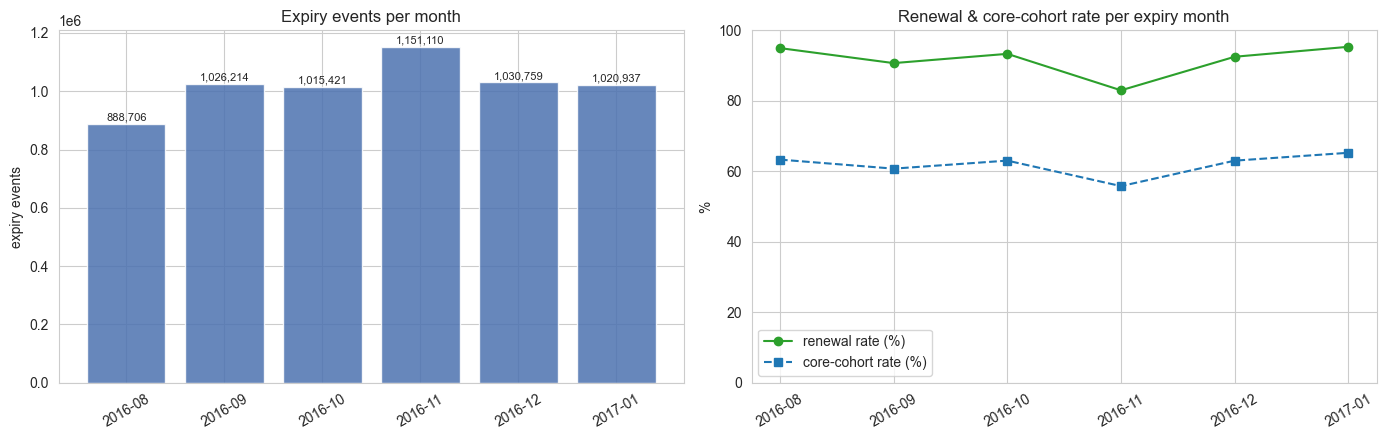

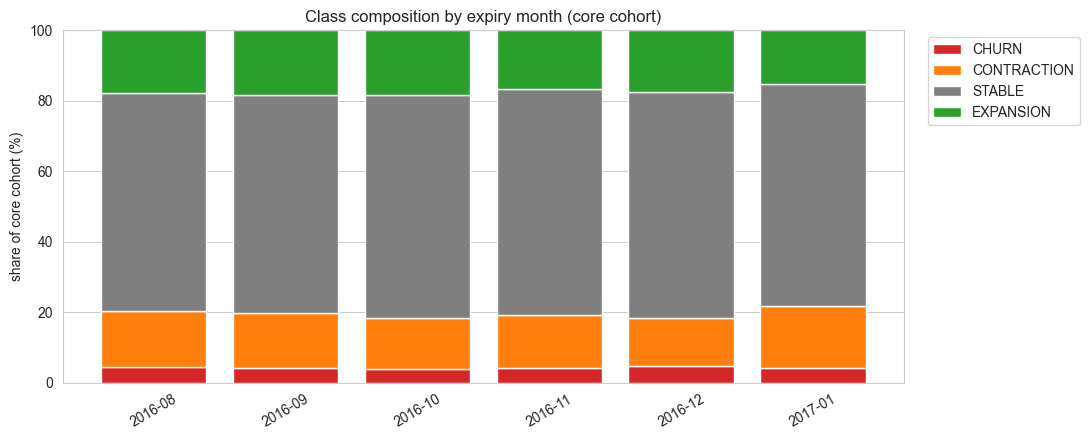

In [7]:
events['_is_core'] = (events['label'] != 'INSUFFICIENT_DATA').astype(int)
monthly = events.groupby('expiry_month').agg(
    events=('msno', 'size'),
    renewal_rate=('renewed', 'mean'),
    mean_pre_rate=('pre_rate', 'mean'),
    mean_post_rate=('post_rate', 'mean'),
    core_rate=('_is_core', 'mean'),
).reset_index()
events.drop(columns='_is_core', inplace=True)
print(monthly.round(3))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(monthly['expiry_month'], monthly['events'], color='#4c72b0', alpha=0.85)
ax[0].set_ylabel('expiry events'); ax[0].set_title('Expiry events per month')
for i, v in enumerate(monthly['events']):
    ax[0].text(i, v + monthly['events'].max() * 0.01, f'{v:,}', ha='center', fontsize=8)
plt.setp(ax[0].get_xticklabels(), rotation=30)
ax[1].plot(monthly['expiry_month'], monthly['renewal_rate'] * 100, 'o-', color='#2ca02c', label='renewal rate (%)')
ax[1].plot(monthly['expiry_month'], monthly['core_rate']    * 100, 's--', color='#1f77b4', label='core-cohort rate (%)')
ax[1].set_ylim(0, 100); ax[1].set_ylabel('%'); ax[1].set_title('Renewal & core-cohort rate per expiry month')
ax[1].legend(); plt.setp(ax[1].get_xticklabels(), rotation=30)
plt.tight_layout(); save_fig('06a_monthly_events_and_renewal_rate'); plt.show()

monthly_lbl = (events[core_mask].groupby(['expiry_month', 'label']).size().unstack(fill_value=0))
monthly_lbl = monthly_lbl.div(monthly_lbl.sum(axis=1), axis=0)
cols = [c for c in CLASS_ORDER if c in monthly_lbl.columns and c != 'INSUFFICIENT_DATA']
monthly_lbl = monthly_lbl[cols]
fig, ax = plt.subplots(figsize=(11, 4.5))
bottom = np.zeros(len(monthly_lbl))
for c in monthly_lbl.columns:
    ax.bar(monthly_lbl.index, monthly_lbl[c] * 100, bottom=bottom, color=PALETTE[c], label=c)
    bottom += monthly_lbl[c].values * 100
ax.set_ylabel('share of core cohort (%)'); ax.set_ylim(0, 100)
ax.set_title('Class composition by expiry month (core cohort)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.setp(ax.get_xticklabels(), rotation=30)
plt.tight_layout(); save_fig('06b_monthly_class_composition'); plt.show()

## 7. Coverage & data-quality audit

In [8]:
n = len(events)
audit = pd.DataFrame({
    'metric': [
        'Total events',
        'Has any pre-log day',
        f'Pre-log ≥ {MIN_DAYS} days',
        'Has any post-log day',
        f'Post-log ≥ {MIN_DAYS} days',
        f'Core cohort (both ≥ {MIN_DAYS})',
        'Renewed in grace window',
        'Silent renewer (renewed & post_total_secs = 0)',
        'Post observed but zero seconds',
        'pre_rate = 0 & post_rate > 0',
        'INSUFFICIENT_DATA',
    ],
    'count': [
        n,
        (events['pre_n_days']  > 0).sum(),
        (events['pre_n_days']  >= MIN_DAYS).sum(),
        (events['post_n_days'] > 0).sum(),
        (events['post_n_days'] >= MIN_DAYS).sum(),
        events['has_evidence'].sum(),
        events['renewed'].sum(),
        events['is_silent_renewer'].sum(),
        events['post_observed_but_silent'].sum(),
        ((events['pre_rate'] == 0) & (events['post_rate'] > 0)).sum(),
        (events['label'] == 'INSUFFICIENT_DATA').sum(),
    ],
})
audit['pct'] = (audit['count'] / n * 100).round(2)
print(audit.to_string(index=False))

                                        metric   count    pct
                                  Total events 6133147 100.00
                           Has any pre-log day 4717446  76.92
                              Pre-log ≥ 7 days 3784500  61.71
                          Has any post-log day 4474895  72.96
                             Post-log ≥ 7 days 3586072  58.47
                        Core cohort (both ≥ 7) 3339490  54.45
                       Renewed in grace window 5605326  91.39
Silent renewer (renewed & post_total_secs = 0) 1257833  20.51
                Post observed but zero seconds       0   0.00
                  pre_rate = 0 & post_rate > 0       0   0.00
                             INSUFFICIENT_DATA 2348647  38.29


## 8. Threshold calibration & robustness for the 0.50 / 1.50 cuts

τ = 0.50 (cuts 0.50 / 1.50) is the selected operating point.

The movement band on the total-volume ratio is chosen so STABLE is **≈ 60% of the
core cohort** (matching the original design balance). The sweep below shows how
the class shares and the label stability move with the threshold τ (band 1 ± τ).

Movement-eligible: 3,623,965   core cohort: 3,784,500
  tau   low  high  flip_vs_0.50  stable_pct_core  pct_STABLE  pct_EXPANSION  pct_CONTRACTION
0.200 0.800 1.200         0.343            0.302       0.316          0.304            0.380
0.250 0.750 1.250         0.274            0.369       0.385          0.278            0.337
0.300 0.700 1.300         0.209            0.431       0.450          0.254            0.296
0.350 0.650 1.350         0.149            0.488       0.510          0.232            0.258
0.400 0.600 1.400         0.094            0.541       0.565          0.213            0.222
0.450 0.550 1.450         0.045            0.588       0.614          0.196            0.190
0.500 0.500 1.500         0.000            0.631       0.659          0.181            0.161
0.550 0.450 1.550         0.040            0.669       0.699          0.167            0.134
0.600 0.400 1.600         0.076            0.704       0.735          0.154            0.111
0.650 0.350 1.65

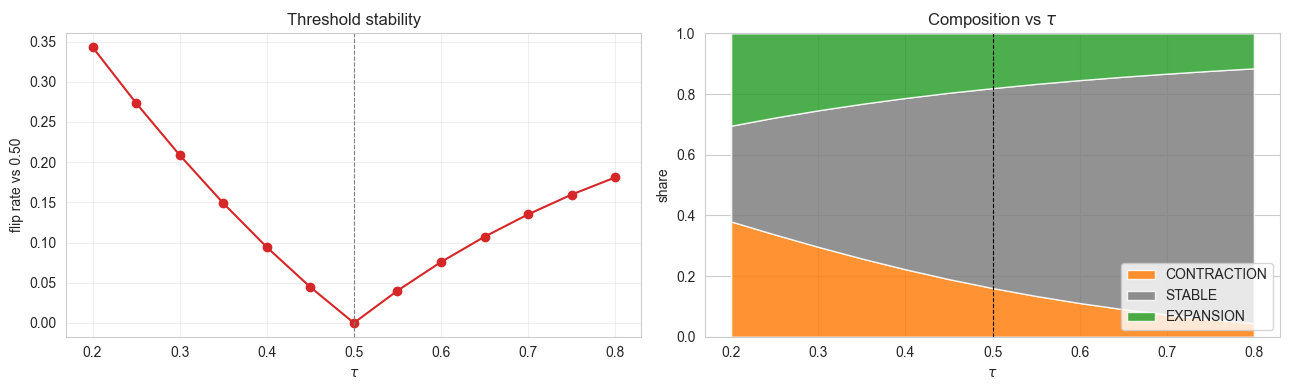

In [9]:
# Calibrate the movement band on the TOTAL-volume ratio so STABLE ~= 60% of the core cohort.
pre_ok = events['has_pre_evidence'].astype(bool)
mv = events.loc[pre_ok & (events['renewed'] == 1) & events['vol_ratio'].notna(), ['vol_ratio']].copy()
# Core cohort = CHURN (pre-ok, not renewed) + forced CONTRACTION (post_total_secs == 0) + movement-eligible
n_churn = int((pre_ok & (events['renewed'] == 0)).sum())
n_post0 = int((pre_ok & (events['renewed'] == 1) & (events['post_total_secs'] == 0)).sum())
core_total = int((events["label"] != "INSUFFICIENT_DATA").sum())
print(f'Movement-eligible: {len(mv):,}   core cohort: {core_total:,}')

def relabel(t):
    lo, hi = 1 - t, 1 + t
    return np.where(mv['vol_ratio'] < lo, 'CONTRACTION',
           np.where(mv['vol_ratio'] > hi, 'EXPANSION', 'STABLE'))
base = relabel(0.50)
rows = []
for t in np.arange(0.20, 0.81, 0.05):
    new = relabel(t)
    n_stable = int((new == 'STABLE').sum())
    rows.append({'tau': round(float(t), 2),
                 'low': round(1 - t, 2), 'high': round(1 + t, 2),
                 'flip_vs_0.50': float((new != base).mean()),
                 'stable_pct_core': n_stable / core_total,
                 'pct_STABLE':      float((new == 'STABLE').mean()),
                 'pct_EXPANSION':   float((new == 'EXPANSION').mean()),
                 'pct_CONTRACTION': float((new == 'CONTRACTION').mean())})
robust = pd.DataFrame(rows)
print(robust.to_string(index=False, float_format=lambda v: f'{v:.3f}'))
print(f"Selected band 0.50 / 1.50 -> STABLE = {(relabel(0.50) == 'STABLE').sum() / core_total:.1%} of core cohort")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(robust['tau'], robust['flip_vs_0.50'], 'o-', color='tab:red')
ax[0].axvline(0.50, color='grey', ls='--', lw=0.8)
ax[0].set_xlabel(r'$\tau$'); ax[0].set_ylabel('flip rate vs 0.50')
ax[0].set_title('Threshold stability'); ax[0].grid(alpha=0.3)

ax[1].stackplot(robust['tau'],
                robust['pct_CONTRACTION'], robust['pct_STABLE'], robust['pct_EXPANSION'],
                labels=['CONTRACTION', 'STABLE', 'EXPANSION'],
                colors=[PALETTE['CONTRACTION'], PALETTE['STABLE'], PALETTE['EXPANSION']], alpha=0.85)
ax[1].axvline(0.50, color='black', ls='--', lw=0.8)
ax[1].set_ylim(0, 1); ax[1].set_title('Composition vs $\\tau$'); ax[1].legend(loc='lower right')
ax[1].set_xlabel(r'$\tau$'); ax[1].set_ylabel('share')
plt.tight_layout(); save_fig('08a_threshold_stability_and_stackplot'); plt.show()

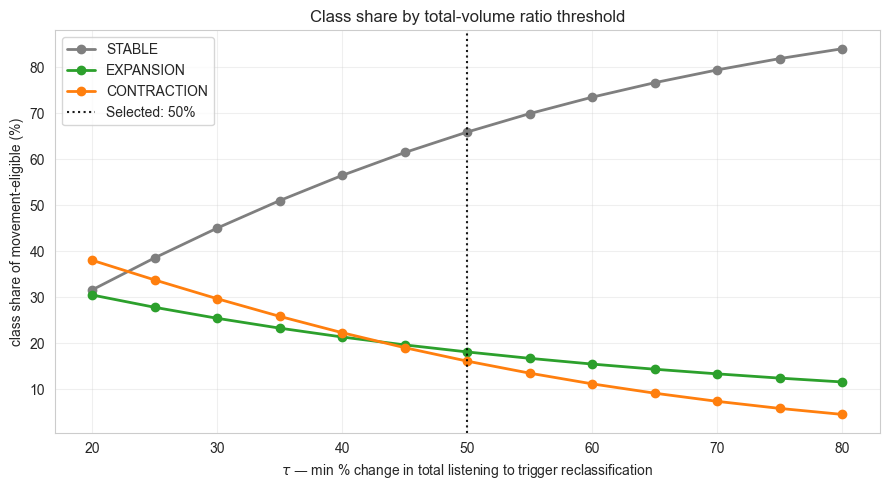

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
for col, cls in [('pct_STABLE', 'STABLE'),
                 ('pct_EXPANSION', 'EXPANSION'),
                 ('pct_CONTRACTION', 'CONTRACTION')]:
    ax.plot(robust['tau'] * 100, robust[col] * 100, marker='o',
            color=PALETTE[cls], label=cls, lw=2)
ax.axvline(50, color='black', ls=':', alpha=0.9, label='Selected: 50%')
ax.set_xlabel(r'$\tau$ — min % change in total listening to trigger reclassification')
ax.set_ylabel('class share of movement-eligible (%)')
ax.set_title('Class share by total-volume ratio threshold')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); save_fig('08b_class_share_by_threshold'); plt.show()

## 8b — Total-volume label vs the per-active-day intensity alternative

The movement label uses the **total-volume ratio** `post_total_secs / pre_total_secs`
— how much the member listened *overall* after renewal versus before. An
alternative we considered was a **per-active-day intensity** ratio
(`(post_secs/post_n_days) / (pre_secs/pre_n_days)`), which controls for how many
days a member happened to log. We rejected it because (i) its small post-window
denominator needs a separate gate to stabilise, discarding renewers with sparse
post-activity, and (ii) a frequency collapse (listening on far fewer days) is
exactly the disengagement we want to capture, not noise to normalise away. The
cell below quantifies how often the two definitions would disagree, as a
robustness check on the choice.

In [11]:
# 8b diagnostic — how often would a per-active-day intensity label disagree with the chosen total-volume label?
_cols = ['label', 'pre_total_secs', 'post_total_secs', 'pre_n_days', 'post_n_days', 'pre_rate', 'post_rate']
try:
    _df = events[_cols].copy()
except NameError:
    _df = pd.read_parquet(OUT / 'events_engineered.parquet', columns=_cols)

_mv = _df[_df['label'].isin(['CONTRACTION', 'STABLE', 'EXPANSION'])].copy()
_n = len(_mv)
print(f'Movement events : {_n:,}')

# Per-active-day intensity ratio and the label it would imply (same band, same post==0 rule)
_intensity = (_mv['post_rate'] / _mv['pre_rate']).values
_int_label = np.where(_mv['post_total_secs'].values == 0, 'CONTRACTION',
             np.where(_intensity < VOL_LOW, 'CONTRACTION',
             np.where(_intensity > VOL_HIGH, 'EXPANSION', 'STABLE')))

_agree = (_int_label == _mv['label'].values)
print(f'Same label under per-active-day intensity : {_agree.mean():.1%}')
print(f'Would flip                                : {(~_agree).mean():.1%} ({(~_agree).sum():,} events)')
print('\nFlip breakdown (chosen total-volume label -> per-active-day label):')
print(pd.crosstab(pd.Series(_mv['label'].values[~_agree], name='total_volume'),
                  pd.Series(_int_label[~_agree],          name='intensity')).to_string())

del _df, _mv; gc.collect()

Movement events : 3,623,965
Same label under per-active-day intensity : 80.8%
Would flip                                : 19.2% (695,704 events)

Flip breakdown (chosen total-volume label -> per-active-day label):
intensity     CONTRACTION  EXPANSION  STABLE
total_volume                                
CONTRACTION             0      10563  311744
EXPANSION             199          0  240565
STABLE              22708     109925       0


18443

## 8c — Retaining renewers with sparse post-activity (no post gate)

An earlier design dropped renewed members with solid pre-evidence but
`post_n_days < 7` to `INSUFFICIENT_DATA`. Under the total-volume definition that
gate is **removed**: the volume ratio has no post-window denominator to
destabilise, so these members are labelled directly from how much total volume
they retained. The cell below confirms how this previously-discarded population
is now classified.

In [12]:
# 8c — how the previously-gated population (renewed, pre>=7, post_n_days<7) is now labelled
_cols = ['label', 'renewed', 'pre_n_days', 'post_n_days', 'pre_total_secs', 'post_total_secs', 'vol_ratio']
try:
    g = events[_cols]
except NameError:
    g = pd.read_parquet(OUT / 'events_engineered.parquet', columns=_cols)
N = len(g)

retained = g[(g['renewed'] == 1) & (g['pre_n_days'] >= MIN_DAYS) & (g['post_n_days'] < MIN_DAYS)]
zero = retained[retained['post_n_days'] == 0]
some = retained[retained['post_n_days'].between(1, MIN_DAYS - 1)]
print(f'Total events                                            : {N:,}')
print(f'Renewed, pre>={MIN_DAYS}d, post<{MIN_DAYS}d (was dropped, now kept) : {len(retained):,} ({len(retained) / N:.2%} of all events)')
print(f'  post_n_days == 0  (renewed, never listened)           : {len(zero):,} ({len(zero) / len(retained):.1%})')
print(f'  post_n_days 1..{MIN_DAYS - 1}  (sparse listening)                  : {len(some):,} ({len(some) / len(retained):.1%})')

print('\nHow these are now labelled (total-volume rule):')
print(retained['label'].value_counts().to_string())
print(f"\n  contraction share of retained set : {(retained['label'] == 'CONTRACTION').mean():.1%}")
print(f"  median total-volume ratio          : {retained['vol_ratio'].median():.2f}")
del g, retained, zero, some; gc.collect()

Total events                                            : 6,133,147
Renewed, pre>=7d, post<7d (was dropped, now kept) : 295,744 (4.82% of all events)
  post_n_days == 0  (renewed, never listened)           : 28,165 (9.5%)
  post_n_days 1..6  (sparse listening)                  : 267,579 (90.5%)

How these are now labelled (total-volume rule):
label
CONTRACTION    221786
STABLE          65924
EXPANSION        8034

  contraction share of retained set : 75.0%
  median total-volume ratio          : 0.24


0

### Decision

**Adopted: the total-volume ratio with no post-window gate (pre gate kept).**

- **Definition.** `vol_ratio = post_total_secs / pre_total_secs`; movement band
  **0.50 / 1.50**, calibrated so STABLE ≈ 60% of the core cohort.
- **No post gate.** The volume ratio has no post-window denominator, so the
  statistical reason for the old `post_n_days ≥ 7` gate disappears. The ~268k
  renewers it used to discard (every one with ≥7 pre-days) are now labelled
  directly; the bulk are contractions (they retained little total volume), and
  the **15,743 `post_total_secs == 0` renewers** — paid then never listened —
  are CONTRACTION rather than dropped.
- **Why volume over per-active-day intensity.** Total volume is a one-sentence,
  defensible engagement measure ("did they listen more or less overall"); it
  removes the two documented weaknesses of the intensity definition (the
  sign-flip cases in §8b and the gate-entanglement here) instead of having to
  justify them. A frequency decline is treated as real disengagement rather than
  normalised away. The per-active-day alternative is retained only as the §8b
  sensitivity check.

This change rebalances the classes (CONTRACTION roughly doubles, STABLE held at
~60% by the recalibrated band) and is the definition used by all downstream
modelling notebooks.

## 9. Behavioural feature distributions by class

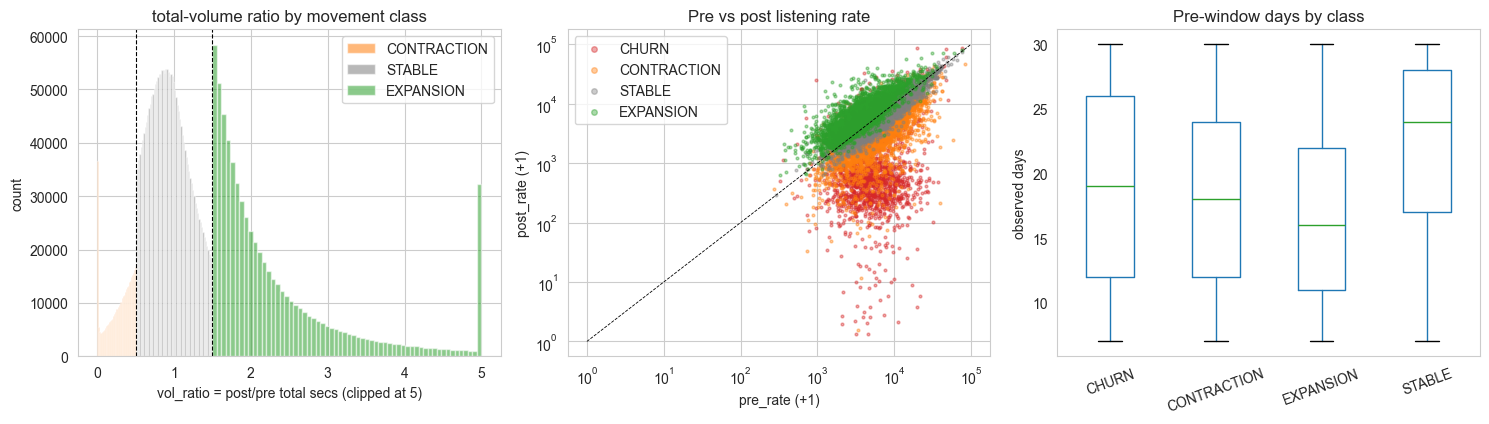

In [13]:
core = events[core_mask]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for cls in ['CONTRACTION', 'STABLE', 'EXPANSION']:
    sub = core.loc[core['label'] == cls, 'vol_ratio'].dropna()
    axes[0].hist(np.clip(sub, 0, 5), bins=60, alpha=0.55, color=PALETTE[cls], label=cls)
axes[0].axvline(0.50, color='black', ls='--', lw=0.8)
axes[0].axvline(1.50, color='black', ls='--', lw=0.8)
axes[0].set_xlabel('vol_ratio = post/pre total secs (clipped at 5)'); axes[0].set_ylabel('count')
axes[0].set_title('total-volume ratio by movement class'); axes[0].legend()

for cls in ['CHURN', 'CONTRACTION', 'STABLE', 'EXPANSION']:
    s = core[core['label'] == cls]
    if len(s) == 0:
        continue
    s = s.sample(min(4000, len(s)), random_state=SEED)
    axes[1].scatter(s['pre_rate'] + 1, s['post_rate'] + 1, s=4, alpha=0.4,
                    color=PALETTE[cls], label=cls)
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].plot([1, 1e5], [1, 1e5], 'k--', lw=0.6)
axes[1].set_xlabel('pre_rate (+1)'); axes[1].set_ylabel('post_rate (+1)')
axes[1].set_title('Pre vs post listening rate'); axes[1].legend(markerscale=2)

core.boxplot(column='pre_n_days', by='label', ax=axes[2], grid=False)
axes[2].set_title('Pre-window days by class'); axes[2].set_xlabel(''); axes[2].set_ylabel('observed days')
plt.suptitle(''); plt.setp(axes[2].get_xticklabels(), rotation=20)
plt.tight_layout(); save_fig('09_behavioural_distributions_by_class'); plt.show()

## 9b — Churners who keep listening after expiry ("engaged churn")

`CHURN` is assigned **purely from the renewal decision** (`renewed == 0`) and, by
design, ignores post-expiry listening. That leaves a grey zone: members who let
their subscription lapse yet **still listened** in the 30-day post window
(grace-period access, a lingering trial, or a late / failed payment). This
section measures how large that group is and what it implies for the label:

* **Prevalence** — active churn as a share of the `CHURN` class and of the cohort.
* **Volume impact** — how much of *all* post-expiry listening they account for.
* **Boundary impact** — if the movement band (0.50 / 1.50) were applied to them,
  how many would read as `STABLE` / `EXPANSION`: behaviourally engaged members the
  label nonetheless calls `CHURN`.
* **Cause signature** — auto-renew vs. explicit-cancel mix, separating "wanted to
  leave" from "meant to stay but the payment lapsed".


CHURN events                                  : 160,535 (4.2% of core cohort)
  still listening post-expiry (post_secs > 0) : 76,966 (47.9% of CHURN)
  silent churn (post_secs == 0)               : 83,569 (52.1% of CHURN)
  active churn as share of all events         : 1.25%
  active churn as share of core cohort        : 2.03%

Post-expiry listening volume held by active churn : 0.3% of ALL post-expiry seconds
Median post volume (active churn) : 816s over median 1 active days

If the movement rule (0.50 / 1.50) were applied to *listening* churners (post>0):
  CONTRACTION :  66,892 (86.9%)
  STABLE      :   7,810 (10.1%)
  EXPANSION   :   2,264 (2.9%)
  -> 10,074 (6.3% of CHURN) look STABLE/EXPANSION by volume but are labelled CHURN
  median would-be vol_ratio (active churn): 0.01

Active-churn transaction signature (event-defining txn):
  is_auto_renew == 1 : 31.2%  (auto-renew ON yet churned -> likely payment/card failure)
  is_cancel     == 1 : 9.7%  (explicit cancellation)


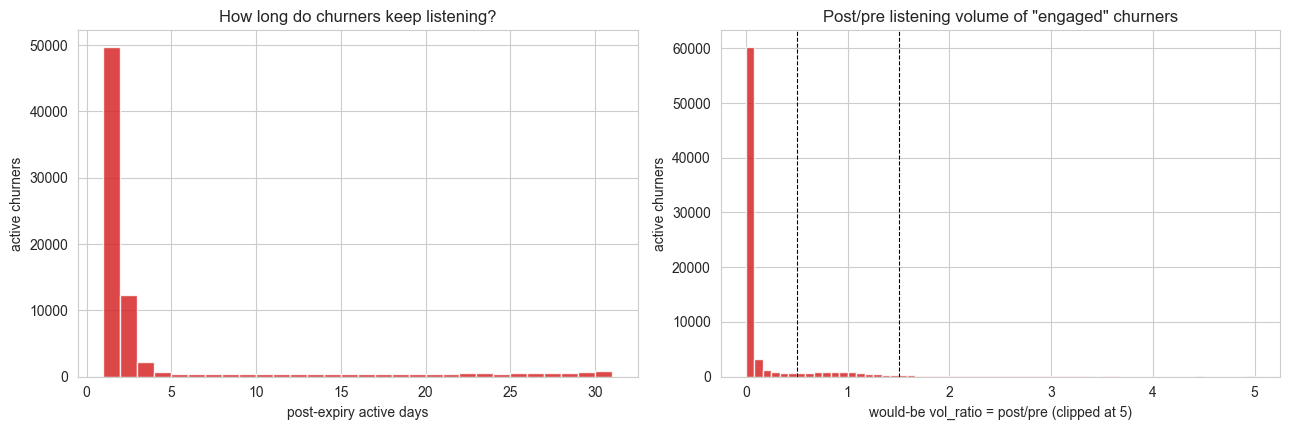

5060

In [14]:
# 9b - churners who keep listening after expiry ("engaged churn")
# CHURN is defined purely by the renewal decision (renewed == 0) and DELIBERATELY
# ignores listening. So a churner can still record post-expiry seconds (grace-window
# / residual access). Quantify how common that is and what it means for the label.
_cols = ['label', 'renewed', 'is_auto_renew', 'is_cancel',
         'pre_total_secs', 'post_total_secs', 'pre_n_days', 'post_n_days']
try:
    ev = events[_cols]
except NameError:
    ev = pd.read_parquet(OUT / 'events_engineered.parquet', columns=_cols)

n_all   = len(ev)
n_core  = int((ev['label'] != 'INSUFFICIENT_DATA').sum())
churn   = ev[ev['label'] == 'CHURN']
n_churn = len(churn)
active  = churn[churn['post_total_secs'] > 0]                 # churned but still listening
n_act   = len(active)

print(f"CHURN events                                  : {n_churn:,} ({n_churn/n_core:.1%} of core cohort)")
print(f"  still listening post-expiry (post_secs > 0) : {n_act:,} ({n_act/n_churn:.1%} of CHURN)")
print(f"  silent churn (post_secs == 0)               : {n_churn-n_act:,} ({1-n_act/n_churn:.1%} of CHURN)")
print(f"  active churn as share of all events         : {n_act/n_all:.2%}")
print(f"  active churn as share of core cohort        : {n_act/n_core:.2%}")

# ---- Impact 1: how much post-expiry listening volume comes from churners ----
tot_post = ev['post_total_secs'].sum()
print(f"\nPost-expiry listening volume held by active churn : {active['post_total_secs'].sum()/tot_post:.1%} of ALL post-expiry seconds")
print(f"Median post volume (active churn) : {active['post_total_secs'].median():,.0f}s over median {active['post_n_days'].median():.0f} active days")

# ---- Impact 2: would-be movement label if the volume rule were applied ----
# Active churners already carry pre-evidence; treat them as if they had renewed.
wr    = (active['post_total_secs'] / active['pre_total_secs'].replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
valid = wr.notna()
would = pd.Series(np.where(wr < VOL_LOW, 'CONTRACTION',
                  np.where(wr > VOL_HIGH, 'EXPANSION', 'STABLE')), index=active.index)[valid]
print("\nIf the movement rule (0.50 / 1.50) were applied to *listening* churners (post>0):")
for c in ['CONTRACTION', 'STABLE', 'EXPANSION']:
    m = (would == c)
    print(f"  {c:<12}: {m.sum():>7,} ({m.mean():.1%})")
engaged = int((wr[valid] >= VOL_LOW).sum())   # retained >= half their pre-volume yet cancelled
print(f"  -> {engaged:,} ({engaged/n_churn:.1%} of CHURN) look STABLE/EXPANSION by volume but are labelled CHURN")
print(f"  median would-be vol_ratio (active churn): {wr[valid].median():.2f}")

# ---- Impact 3: why did they churn? auto-renew / cancel signature ----
print("\nActive-churn transaction signature (event-defining txn):")
print(f"  is_auto_renew == 1 : {active['is_auto_renew'].mean():.1%}  (auto-renew ON yet churned -> likely payment/card failure)")
print(f"  is_cancel     == 1 : {active['is_cancel'].mean():.1%}  (explicit cancellation)")

# ---- Figure ----
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].hist(active['post_n_days'], bins=range(1, 32), color=PALETTE['CHURN'], alpha=0.85)
ax[0].set_xlabel('post-expiry active days'); ax[0].set_ylabel('active churners')
ax[0].set_title('How long do churners keep listening?')
ax[1].hist(np.clip(wr[valid], 0, 5), bins=60, color=PALETTE['CHURN'], alpha=0.85)
ax[1].axvline(VOL_LOW,  color='black', ls='--', lw=0.8)
ax[1].axvline(VOL_HIGH, color='black', ls='--', lw=0.8)
ax[1].set_xlabel('would-be vol_ratio = post/pre (clipped at 5)'); ax[1].set_ylabel('active churners')
ax[1].set_title('Post/pre listening volume of "engaged" churners')
plt.tight_layout(); save_fig('09b_engaged_churn_analysis'); plt.show()

del ev, churn, active; gc.collect()


In [ ]:
# 9c — Audit: active churners with possible pre-E renewals / extensions
# Purpose:
# Some CHURN events keep listening after E. One possible explanation is that the
# renewal rule misses paid renewals posted BEFORE E that already extend membership beyond E.
#
# This checks whether active churners have a paid non-cancel transaction:
#   - after or on the event-defining transaction date,
#   - before E,
#   - with membership_expire_date > E.
#
# If many exist, the current renewal rule [E, E+30] is too strict.

import numpy as np
import pandas as pd
import gc

# Recreate the active-churn population used in the following audit
active_churn = events.loc[
    (events["label"] == "CHURN") &
    (events["post_total_secs"] > 0),
    ["msno", "E", "last_pre_txn_date", "pre_total_secs", "post_total_secs",
     "pre_n_days", "post_n_days", "is_auto_renew", "is_cancel"]
].copy()

print(f"Active churn events to audit: {len(active_churn):,}")

# Paid, non-cancel transactions only
paid_txn = txn.loc[
    (txn["actual_amount_paid"] > 0) &
    (txn["is_cancel"] == 0),
    ["msno", "transaction_date", "membership_expire_date",
     "actual_amount_paid", "plan_list_price", "payment_plan_days",
     "payment_method_id", "is_auto_renew", "is_cancel"]
].copy()

# Narrow date scan before merging to reduce memory
min_date = active_churn["last_pre_txn_date"].min()
max_date = active_churn["E"].max()

paid_txn = paid_txn[
    (paid_txn["transaction_date"] >= min_date) &
    (paid_txn["transaction_date"] <= max_date)
].copy()

cand = paid_txn.merge(active_churn[["msno", "E", "last_pre_txn_date"]],
                      on="msno", how="inner")

# Main audit: paid extension posted before E but extending beyond E
pre_E_extension = cand[
    (cand["transaction_date"] >= cand["last_pre_txn_date"]) &
    (cand["transaction_date"] < cand["E"]) &
    (cand["membership_expire_date"] > cand["E"])
].copy()

# Collapse to one row per active churn event
pre_E_extension_first = (
    pre_E_extension
    .sort_values(["msno", "E", "transaction_date", "membership_expire_date"])
    .groupby(["msno", "E"], as_index=False)
    .head(1)
)

n_active = len(active_churn)
n_missed_pre_E = pre_E_extension_first[["msno", "E"]].drop_duplicates().shape[0]
n_churn = int((events["label"] == "CHURN").sum())
n_core = int((events["label"] != "INSUFFICIENT_DATA").sum())

print("\nPossible missed pre-E renewals among active churners")
print(f"  active churn events                    : {n_active:,}")
print(f"  pre-E paid extensions found            : {n_missed_pre_E:,}")
print(f"  share of active churn                  : {n_missed_pre_E / n_active:.1%}")
print(f"  share of all CHURN                     : {n_missed_pre_E / n_churn:.1%}")
print(f"  share of core cohort                   : {n_missed_pre_E / n_core:.2%}")

if n_missed_pre_E > 0:
    print("\nExample possible missed renewals:")
    display(
        pre_E_extension_first[
            ["msno", "E", "last_pre_txn_date", "transaction_date",
             "membership_expire_date", "actual_amount_paid",
             "plan_list_price", "payment_plan_days",
             "payment_method_id", "is_auto_renew"]
        ].head(20)
    )

    print("\nTiming summary:")
    tmp = pre_E_extension_first.copy()
    tmp["days_before_E"] = (tmp["E"] - tmp["transaction_date"]).dt.days
    tmp["extension_days_beyond_E"] = (tmp["membership_expire_date"] - tmp["E"]).dt.days

    display(
        tmp[["days_before_E", "extension_days_beyond_E",
             "actual_amount_paid", "payment_plan_days"]]
        .describe()
        .round(2)
    )

# Optional broader audit:
# paid non-cancel transaction after the event-defining txn, before grace end,
# extending membership beyond E. This includes pre-E and post-E cases.
grace_audit = active_churn[["msno", "E", "last_pre_txn_date"]].copy()
grace_audit["grace_end"] = grace_audit["E"] + pd.Timedelta(days=GRACE_DAYS)

paid_txn2 = txn.loc[
    (txn["actual_amount_paid"] > 0) &
    (txn["is_cancel"] == 0),
    ["msno", "transaction_date", "membership_expire_date",
     "actual_amount_paid", "plan_list_price", "payment_plan_days",
     "payment_method_id", "is_auto_renew", "is_cancel"]
].copy()

paid_txn2 = paid_txn2[
    (paid_txn2["transaction_date"] >= grace_audit["last_pre_txn_date"].min()) &
    (paid_txn2["transaction_date"] <= grace_audit["grace_end"].max())
].copy()

cand2 = paid_txn2.merge(grace_audit, on="msno", how="inner")

broad_extension = cand2[
    (cand2["transaction_date"] >= cand2["last_pre_txn_date"]) &
    (cand2["transaction_date"] <= cand2["grace_end"]) &
    (cand2["membership_expire_date"] > cand2["E"])
].copy()

broad_first = (
    broad_extension
    .sort_values(["msno", "E", "transaction_date", "membership_expire_date"])
    .groupby(["msno", "E"], as_index=False)
    .head(1)
)

n_broad = broad_first[["msno", "E"]].drop_duplicates().shape[0]

print("\nBroader possible missed-renewal audit")
print("Paid extension after event-defining txn and within grace horizon, extending beyond E:")
print(f"  possible missed renewals               : {n_broad:,}")
print(f"  share of active churn                  : {n_broad / n_active:.1%}")
print(f"  share of all CHURN                     : {n_broad / n_churn:.1%}")

# Breakdown: was the extension posted before or after E?
if n_broad > 0:
    broad_first["posted_before_E"] = broad_first["transaction_date"] < broad_first["E"]
    print("\nPosting timing breakdown:")
    print(
        broad_first["posted_before_E"]
        .map({True: "posted before E", False: "posted on/after E"})
        .value_counts()
        .to_string()
    )

del paid_txn, cand, pre_E_extension, paid_txn2, cand2, broad_extension
gc.collect()

Active churn events to audit: 76,966

Possible missed pre-E renewals among active churners
  active churn events                    : 76,966
  pre-E paid extensions found            : 0
  share of active churn                  : 0.0%
  share of all CHURN                     : 0.0%
  share of core cohort                   : 0.00%

Broader possible missed-renewal audit
Paid extension after event-defining txn and within grace horizon, extending beyond E:
  possible missed renewals               : 0
  share of active churn                  : 0.0%
  share of all CHURN                     : 0.0%


0

## 9d — Forward grace-window sensitivity (30 → 60 days after E)

§9c looked *backwards* (renewals posted before `E` that already extend past it).
This cell looks *forwards*: the renewal decision (§2) only counts a paid, non-cancel
transaction within **30 days** of expiry, so a member whose payment lands in
**(30, 60]** days after `E` — a retry, a delayed manual renewal, or a later
win-back — is currently labelled `CHURN`. We reconstruct the first paid renewal
per event from the raw transactions and ask **how many current `CHURN` events
would flip to renewed under a 60-day grace window**, i.e. how many churners we may
be mislabelling. Two guards keep the answer honest:

* **Censoring** — only events whose full 60-day window falls inside the
  transaction data (`E + 60 ≤ last observed transaction`) are counted.
* **Genuine renewal vs. re-acquisition** — we separate late payments that actually
  **extend membership past `E`** (true late renewals) from paid rows that don't
  (a new/backdated plan, closer to a win-back than a continuous renewal).


Transaction coverage ends: 2017-03-31  (events with E+60 beyond this are censored)

CHURN events (current 30d rule)               : 160,535
  fully observable at 60d                     : 159,379 (99.3% of CHURN)
  -> paid txn in (30, 60] after E             : 32,859 (20.62% of observable CHURN)
     of which it EXTENDS membership past E     : 32,859 (20.62%)  <- genuine late renewals (mislabelled)
     no extension (new plan / backdated)       : 0

Days-after-E of the first late paid renewal (observable CHURN):
first_paid_day
(30, 35]    15730
(35, 40]     4683
(40, 45]     3887
(45, 50]     3301
(50, 60]     5258

Renewal rate as the grace window grows (fully-observable events):
  grace 30d -> renewal rate 88.197%
  grace 35d -> renewal rate 89.136%
  grace 40d -> renewal rate 89.315%
  grace 45d -> renewal rate 89.443%
  grace 50d -> renewal rate 89.547%
  grace 60d -> renewal rate 89.752%


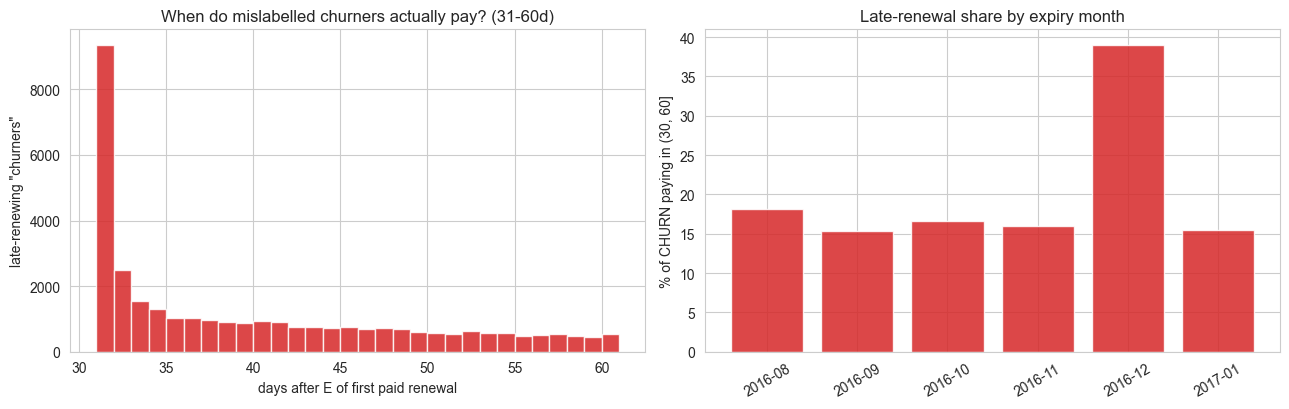

10502

In [16]:
# 9d - Forward grace-window sensitivity: extend CHURN grace 30 -> 60 days after E
# Current renewal rule (section 2): renewed = paid non-cancel txn in [E, E+30].
# A member whose payment lands in (30, 60] days after E is currently labelled CHURN.
# Q: how many current CHURN events have a LATE paid renewal in (30, 60]? Those are
#    late renewers the 30-day rule mislabels. A censoring guard keeps only events
#    whose full 60-day window lies inside the transaction data.
try:
    ev  = events[['msno', 'E', 'expiry_month', 'label', 'renewed']].copy()
    _tx = txn
except NameError:
    import pyarrow.parquet as pq
    ev = pd.read_parquet(OUT / 'events_engineered.parquet',
                         columns=['msno', 'E', 'expiry_month', 'label', 'renewed'])
    ev['E'] = pd.to_datetime(ev['E'])
    _tx = pd.concat([pq.read_table(DATA / f, columns=['msno', 'transaction_date',
                     'membership_expire_date', 'actual_amount_paid', 'is_cancel']).to_pandas()
                     for f in ['transactions.parquet', 'transactions_v2.parquet']], ignore_index=True)
    for _c in ['transaction_date', 'membership_expire_date']:
        _tx[_c] = pd.to_datetime(_tx[_c], format='%Y%m%d')

EXT_GRACE = 60
max_txn = _tx['transaction_date'].max()

# paid, non-cancel transactions, restricted to the cohort's forward window
paid = _tx.loc[(_tx['actual_amount_paid'] > 0) & (_tx['is_cancel'] == 0),
               ['msno', 'transaction_date', 'membership_expire_date']]
w_lo, w_hi = ev['E'].min(), ev['E'].max() + pd.Timedelta(days=EXT_GRACE)
paid = paid[(paid['transaction_date'] >= w_lo) & (paid['transaction_date'] <= w_hi)]

# earliest paid renewal within [E, E+60] per event (+ does it actually extend past E?)
c = ev.merge(paid, on='msno', how='inner')
c['d'] = (c['transaction_date'] - c['E']).dt.days
c = c[(c['d'] >= 0) & (c['d'] <= EXT_GRACE)]
c['extends'] = c['membership_expire_date'] > c['E']
first = (c.sort_values(['msno', 'E', 'd'])
           .groupby(['msno', 'E'], as_index=False)
           .agg(first_paid_day=('d', 'first'), first_extends=('extends', 'first')))
ev = ev.merge(first, on=['msno', 'E'], how='left')
ev['obs60'] = (ev['E'] + pd.Timedelta(days=EXT_GRACE)) <= max_txn
del c, first, paid; gc.collect()

churn     = ev[ev['label'] == 'CHURN']
n_churn   = len(churn)
churn_obs = churn[churn['obs60']]                                  # censoring-safe base
late      = churn_obs[churn_obs['first_paid_day'].notna()]         # any paid txn in (30, 60]
late_ext  = late[late['first_extends']]                            # ...and it extends membership past E

print(f"Transaction coverage ends: {max_txn.date()}  (events with E+60 beyond this are censored)")
print(f"\nCHURN events (current 30d rule)               : {n_churn:,}")
print(f"  fully observable at 60d                     : {len(churn_obs):,} ({len(churn_obs)/n_churn:.1%} of CHURN)")
print(f"  -> paid txn in (30, 60] after E             : {len(late):,} ({len(late)/len(churn_obs):.2%} of observable CHURN)")
print(f"     of which it EXTENDS membership past E     : {len(late_ext):,} ({len(late_ext)/len(churn_obs):.2%})  <- genuine late renewals (mislabelled)")
print(f"     no extension (new plan / backdated)       : {len(late)-len(late_ext):,}")

print("\nDays-after-E of the first late paid renewal (observable CHURN):")
print(pd.cut(late['first_paid_day'], [30, 35, 40, 45, 50, 60]).value_counts().sort_index().to_string())

print("\nRenewal rate as the grace window grows (fully-observable events):")
obs = ev[ev['obs60']]
for G in [30, 35, 40, 45, 50, 60]:
    print(f"  grace {G:>2}d -> renewal rate {(obs['first_paid_day'] <= G).mean():.3%}")

# figure
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].hist(late['first_paid_day'], bins=range(31, 62), color=PALETTE['CHURN'], alpha=0.85)
ax[0].set_xlabel('days after E of first paid renewal'); ax[0].set_ylabel('late-renewing "churners"')
ax[0].set_title('When do mislabelled churners actually pay? (31-60d)')
bym = churn_obs.assign(l=churn_obs['first_paid_day'].notna()).groupby('expiry_month')['l'].mean() * 100
ax[1].bar(bym.index, bym.values, color=PALETTE['CHURN'], alpha=0.85)
ax[1].set_ylabel('% of CHURN paying in (30, 60]'); ax[1].set_title('Late-renewal share by expiry month')
plt.setp(ax[1].get_xticklabels(), rotation=30)
plt.tight_layout(); save_fig('09d_grace_window_60d_sensitivity'); plt.show()

del ev, churn, churn_obs, late, late_ext, obs; gc.collect()


## 9e — Bulletproofing the churn label against the official KKBox definition

`§9c/§9d` showed our `renewed`-based rule can miss late and pre-`E` renewals. To make
the churn label defensible we go to the source: the competition's own labeller
(`old_files/WSDMChurnLabeller.scala`) and the released ground-truth `is_churn`
files (`train.csv`, `train_v2.csv`). The official definition differs from ours in
three ways worth stating explicitly:

1. **Effective expiry, not the raw event date.** A user's expiry is the
   `membership_expire_date` of the *last* transaction in a history window — so an
   **early renewal that pushes the expiry date back is already absorbed** (renewals
   extend it, cancels shorten it). Our per-`(msno, E)` events instead fire at *every*
   intermediate expiry, which can invent churn events a user already renewed past.
2. **Renewal gap ≥ 30, not a fixed window.** Churn = no non-cancel transaction
   within 30 days *after* the effective expiry (interim cancels can pull it earlier).
3. **Any `is_cancel == 0` counts as a renewal** (KKBox ignores amount); our rule
   also requires `actual_amount_paid > 0`.

**Cell A** re-implements the official labeller in pandas and checks it against the
released `is_churn` labels (agreement should be near-total if the logic is faithful).
**Cell B** then applies the two failure modes — *pre-`E` pushback* and *forward
gap < 30* — to our own CHURN events to count how many we may be mislabelling.


In [17]:
# 9e-A - Replicate the OFFICIAL KKBox churn labeller and validate on train.csv / train_v2.csv
# Official logic (WSDMChurnLabeller.scala):
#   1. effective last_expire per user = expiry of the LAST transaction in a 1-month history
#      window (same-day: renewals extend / cancels shorten / subscribe precedes cancel).
#   2. churn = NO non-cancel ("renewal") transaction within 30 days AFTER that last_expire,
#      where interim cancels before the first renewal can pull the expiration earlier.
#      gap >= 30 days (or no renewal at all) => churn.
# NOTE vs our label: KKBox counts ANY is_cancel==0 txn as a renewal (amount not required),
# and keys off the renewal GAP, not a fixed [E, E+30] window.

def kkbox_churn(tx, hist_lo, hist_hi, exp_lo, exp_hi):
    tx = tx[['msno', 'transaction_date', 'membership_expire_date', 'is_cancel']]
    # (1) effective last expiration from the history window
    H = tx[(tx['transaction_date'] >= hist_lo) & (tx['transaction_date'] <= hist_hi)]
    H = H.sort_values(['msno', 'transaction_date', 'is_cancel', 'membership_expire_date'])
    cand = (H.groupby('msno', as_index=False).tail(1)[['msno', 'membership_expire_date']]
              .rename(columns={'membership_expire_date': 'last_expire'}))
    cand = cand[(cand['last_expire'] >= exp_lo) & (cand['last_expire'] <= exp_hi)].reset_index(drop=True)
    # (2) future transactions for these candidates
    F = tx[tx['transaction_date'] > hist_hi].merge(cand[['msno']], on='msno', how='inner')
    # first renewal (non-cancel) after expiration
    ren = (F[F['is_cancel'] == 0].sort_values(['msno', 'transaction_date'])
             .groupby('msno', as_index=False).head(1)[['msno', 'transaction_date']]
             .rename(columns={'transaction_date': 'first_ren_date'}))
    cand = cand.merge(ren, on='msno', how='left')
    # interim cancels strictly before the first renewal pull the expiration earlier
    cb = F[F['is_cancel'] == 1].merge(cand[['msno', 'first_ren_date']], on='msno', how='inner')
    cb = cb[cb['transaction_date'] < cb['first_ren_date']]
    cb_min = cb.groupby('msno')['membership_expire_date'].min().rename('cancel_min_expire')
    cand = cand.merge(cb_min, on='msno', how='left')
    cand['adj_expire'] = cand[['last_expire', 'cancel_min_expire']].min(axis=1)
    cand['gap'] = (cand['first_ren_date'] - cand['adj_expire']).dt.days
    cand['pred_churn'] = (cand['first_ren_date'].isna() | (cand['gap'] >= 30)).astype(int)
    return cand[['msno', 'last_expire', 'gap', 'pred_churn']]

t17 = txn[txn['transaction_date'] >= pd.Timestamp('2016-12-01')]
specs = {   # official file -> (history_lo, history_hi, expire_lo, expire_hi)
    'train.csv':    ('2017-01-01', '2017-01-31', '2017-02-01', '2017-02-28'),
    'train_v2.csv': ('2017-02-01', '2017-02-28', '2017-03-01', '2017-03-31'),
}
for fname, win in specs.items():
    fp = DATA.parent / 'old_files' / fname
    if not fp.exists():
        print(f'{fname} not found — skipping'); continue
    off = pd.read_csv(fp)                                   # msno, is_churn
    pred = kkbox_churn(t17, *map(pd.Timestamp, win))
    cmp = off.merge(pred[['msno', 'pred_churn']], on='msno', how='left')
    matched = cmp.dropna(subset=['pred_churn']).copy()
    matched['pred_churn'] = matched['pred_churn'].astype(int)
    acc = (matched['is_churn'] == matched['pred_churn']).mean()
    print(f"\n{fname}: official {len(off):,} rows | our candidates {len(pred):,} | "
          f"matched {len(matched):,} ({cmp['pred_churn'].notna().mean():.1%} coverage)")
    print(f"  official churn rate {off['is_churn'].mean():.3%} | our churn rate {pred['pred_churn'].mean():.3%}")
    print(f"  AGREEMENT with official is_churn : {acc:.3%}")
    print(pd.crosstab(matched['is_churn'], matched['pred_churn'],
                      rownames=['official'], colnames=['ours(pred)']).to_string())
del t17; gc.collect()



train.csv: official 992,931 rows | our candidates 853,797 | matched 853,769 (86.0% coverage)
  official churn rate 6.392% | our churn rate 3.336%
  AGREEMENT with official is_churn : 98.768%
ours(pred)       0      1
official                 
0           814943    168
1            10350  28308

train_v2.csv: official 970,960 rows | our candidates 850,763 | matched 829,226 (85.4% coverage)
  official churn rate 8.994% | our churn rate 3.953%
  AGREEMENT with official is_churn : 96.991%
ours(pred)       0      1
official                 
0           778497   7630
1            17321  25778


35

In [18]:
# 9e-B - Bulletproof OUR churn label: pre-E "expiration pushback" + KKBox 30-day gap
# Two ways the current rule (paid txn in [E, E+30]) can MISLABEL a churn:
#   (i)  pre-E pushback - a non-cancel txn dated <= E already extends membership past E,
#        so the user renewed EARLY, coverage continues, and E is not a real churn point.
#   (ii) forward gap < 30 - the next renewal (any non-cancel txn) lands within 30 days
#        after E (the KKBox rule), so KKBox would count it as renewed, not churn.
churn_ev = events.loc[events['label'] == 'CHURN', ['msno', 'E', 'expiry_month']].copy()
churn_users = set(churn_ev['msno'])
nc = txn.loc[(txn['is_cancel'] == 0) & (txn['msno'].isin(churn_users)),
             ['msno', 'transaction_date', 'membership_expire_date']]
n_ch = len(churn_ev)

# (i) pre-E pushback: max coverage end among the user's non-cancel txns dated <= E
pe = churn_ev.merge(nc, on='msno', how='inner')
pe = pe[pe['transaction_date'] <= pe['E']]
cov_end = pe.groupby(['msno', 'E'])['membership_expire_date'].max().rename('cov_end_preE')
churn_ev = churn_ev.merge(cov_end, on=['msno', 'E'], how='left')
churn_ev['preE_pushback']  = churn_ev['cov_end_preE'] > churn_ev['E']
churn_ev['preE_days_past'] = (churn_ev['cov_end_preE'] - churn_ev['E']).dt.days
del pe; gc.collect()

# (ii) forward renewal within 30 days after E (any non-cancel txn in (E, E+30])
fw = churn_ev[['msno', 'E']].merge(nc, on='msno', how='inner')
fw = fw[(fw['transaction_date'] > fw['E']) &
        (fw['transaction_date'] <= fw['E'] + pd.Timedelta(days=30))]
has_fwd = fw.groupby(['msno', 'E']).size().rename('fwd30')
churn_ev = churn_ev.merge(has_fwd, on=['msno', 'E'], how='left')
churn_ev['fwd_renew_30'] = churn_ev['fwd30'].fillna(0) > 0
del fw, nc; gc.collect()

p_i    = int(churn_ev['preE_pushback'].sum())
p_ii   = int(churn_ev['fwd_renew_30'].sum())
either = int((churn_ev['preE_pushback'] | churn_ev['fwd_renew_30']).sum())
n_core = int((events['label'] != 'INSUFFICIENT_DATA').sum())
print(f"Current CHURN events                                   : {n_ch:,}")
print(f"  (i)  pre-E pushback (coverage already extends past E) : {p_i:,} ({p_i/n_ch:.1%} of CHURN)")
print(f"  (ii) forward renewal within 30d of E                 : {p_ii:,} ({p_ii/n_ch:.1%} of CHURN)")
print(f"  (i or ii) arguably NOT churn                         : {either:,} ({either/n_ch:.1%} of CHURN, {either/n_core:.2%} of core)")
print(f"  bulletproofed CHURN (survives both checks)           : {n_ch-either:,}")

pp = churn_ev[churn_ev['preE_pushback']]
if len(pp):
    print(f"\nPre-E pushback: median coverage extends {pp['preE_days_past'].median():.0f} days past E "
          f"(p90 {pp['preE_days_past'].quantile(0.9):.0f}d, max {pp['preE_days_past'].max():.0f}d)")
    print("Pre-E pushback rate by expiry month:")
    print((churn_ev.groupby('expiry_month')['preE_pushback'].mean() * 100).round(1).to_string())

del churn_ev, pp; gc.collect()


Current CHURN events                                   : 160,535
  (i)  pre-E pushback (coverage already extends past E) : 0 (0.0% of CHURN)
  (ii) forward renewal within 30d of E                 : 4,048 (2.5% of CHURN)
  (i or ii) arguably NOT churn                         : 4,048 (2.5% of CHURN, 0.11% of core)
  bulletproofed CHURN (survives both checks)           : 156,487


0

## 10. Historical (pre-`E`) transaction aggregates — candidate predictor features

In [19]:
tx_ev = txn.merge(events[['msno', 'E']], on='msno', how='inner')
tx_ev = tx_ev[tx_ev['transaction_date'] < tx_ev['E']]
hist_agg = tx_ev.groupby(['msno', 'E']).agg(
    n_hist_txns       = ('transaction_date',    'size'),
    first_txn_date    = ('transaction_date',    'min'),
    last_hist_txn_date= ('transaction_date',    'max'),
    mean_hist_price   = ('plan_list_price',     'mean'),
    median_hist_paid  = ('actual_amount_paid',  'median'),
    cancel_rate       = ('is_cancel',           'mean'),
    auto_renew_rate   = ('is_auto_renew',       'mean'),
).reset_index()
# Most common historical payment method per event — vectorised (a per-group Series.mode
# lambda is O(groups) pure-Python and hangs on this many groups). Tie-break -> smallest id,
# matching pandas Series.mode().iat[0].
mode_pay = (tx_ev.groupby(['msno', 'E', 'payment_method_id']).size().reset_index(name='_cnt')
            .sort_values(['msno', 'E', '_cnt', 'payment_method_id'],
                         ascending=[True, True, True, False])
            .groupby(['msno', 'E'], as_index=False).tail(1)
            [['msno', 'E', 'payment_method_id']]
            .rename(columns={'payment_method_id': 'mode_pay_method'}))
hist_agg = hist_agg.merge(mode_pay, on=['msno', 'E'], how='left')
hist_agg['tenure_days']  = (hist_agg['E'] - hist_agg['first_txn_date']).dt.days
hist_agg['recency_days'] = (hist_agg['E'] - hist_agg['last_hist_txn_date']).dt.days
hist_agg = hist_agg.drop(columns=['first_txn_date', 'last_hist_txn_date'])
events = events.merge(hist_agg, on=['msno', 'E'], how='left')
events['has_hist_txn'] = events['n_hist_txns'].notna().astype(int)
del tx_ev, hist_agg, mode_pay; gc.collect()
print('Historical txn coverage:', events['has_hist_txn'].mean())
events[['n_hist_txns', 'mean_hist_price', 'cancel_rate', 'auto_renew_rate',
        'tenure_days', 'recency_days']].describe().round(2)


Historical txn coverage: 0.9996303692052384


,n_hist_txns,mean_hist_price,cancel_rate,auto_renew_rate,tenure_days,recency_days
count,6130880.00,6130880.00,6130880.00,6130880.00,6130880.00,6130880.00
mean,13.06,138.30,0.02,0.83,420.39,28.86
std,8.07,139.61,0.04,0.36,228.43,36.07
min,1.00,0.00,0.00,0.00,1.00,1.00
25%,6.00,99.00,0.00,1.00,223.00,27.00
50%,13.00,131.70,0.00,1.00,457.00,30.00
75%,20.00,149.00,0.00,1.00,626.00,31.00
max,244.00,2000.00,1.00,1.00,761.00,751.00


## 11. Member demographics merge

In [20]:
members_path = DATA / 'members_v3.parquet'
if members_path.exists():
    members = pq.read_table(members_path,
                            columns=['msno', 'city', 'bd', 'gender',
                                     'registered_via', 'registration_init_time']).to_pandas()
    members['registration_init_time'] = pd.to_datetime(
        members['registration_init_time'], format='%Y%m%d', errors='coerce')
    members['bd'] = members['bd'].where(members['bd'].between(10, 90))
    events = events.merge(members, on='msno', how='left')
    print('Demographic missing %:')
    print((events[['city', 'bd', 'gender', 'registered_via']].isna().mean() * 100).round(2))
else:
    print('members_v3.parquet missing — skipping.')

Demographic missing %:
city              11.60
bd                60.26
gender            11.60
registered_via    11.60
dtype: float64


## 11A — Prior-renewal history features (point-in-time)

"A user who has renewed six times is more likely to renew a seventh." That
signal is captured *as features*, computed strictly from transactions dated
before each event's expiry `E`, so it generalises across users without leaking
identity through the splits. Adds `n_prior_renewals`, `n_prior_cancels`,
`n_prior_autorenew`, and `prior_renewal_rate` (renewals ÷ prior transactions).

In [21]:
# Point-in-time history: count each user's prior paid renewals BEFORE E (no leakage)
prior = txn.merge(events[['msno', 'E']], on='msno', how='inner')
prior = prior[prior['transaction_date'] < prior['E']].copy()
prior['is_paid_renewal'] = ((prior['actual_amount_paid'] > 0) & (prior['is_cancel'] == 0)).astype(int)
prior_agg = prior.groupby(['msno', 'E']).agg(
    n_prior_renewals =('is_paid_renewal', 'sum'),
    n_prior_cancels  =('is_cancel',       'sum'),
    n_prior_autorenew=('is_auto_renew',   'sum'),
).reset_index()
events = events.merge(prior_agg, on=['msno', 'E'], how='left')
for c in ['n_prior_renewals', 'n_prior_cancels', 'n_prior_autorenew']:
    events[c] = events[c].fillna(0).astype('int32')
# Share of a user's prior transactions that were successful paid renewals
denom = events['n_hist_txns'].fillna(0)
events['prior_renewal_rate'] = np.where(denom > 0,
                                        events['n_prior_renewals'] / denom.replace(0, np.nan), 0.0)
events['prior_renewal_rate'] = events['prior_renewal_rate'].fillna(0.0)
del prior, prior_agg; gc.collect()
print('Prior-renewal feature coverage:')
print(events[['n_prior_renewals', 'n_prior_cancels', 'n_prior_autorenew', 'prior_renewal_rate']]
      .describe().round(2))

Prior-renewal feature coverage:
       n_prior_renewals  n_prior_cancels  n_prior_autorenew  \
count        6133147.00       6133147.00         6133147.00   
mean              12.65             0.24              11.92   
std                7.88             0.54               8.71   
min                0.00             0.00               0.00   
25%                6.00             0.00               4.00   
50%               13.00             0.00              12.00   
75%               19.00             0.00              19.00   
max               80.00            19.00              80.00   

       prior_renewal_rate  
count          6133147.00  
mean                 0.93  
std                  0.22  
min                  0.00  
25%                  0.96  
50%                  1.00  
75%                  1.00  
max                  1.00  


## 11B — Time-before-renewal scan: horizon features + sequence panel

A single chunked pass over the daily logs serves both heavy modelling needs:

1. **Horizon features** for the *time-before-renewal* experiment. For each
   horizon `h ∈ {1, 7, 14, 30, 60}` days, behavioural features are computed over
   a sliding 30-day window **ending at `E − h`** — i.e. only what is known `h`
   days before expiry. Columns `h{h}_secs`, `h{h}_ndays`, `h{h}_rate`,
   `h{h}_active`. The label is *not* recomputed, so all horizons stay directly
   comparable.
2. **Sequence panel** (`events_daily_panel.parquet`): the daily series of
   `total_secs`, `num_100`, `num_unq`, `num_25` over the `SEQ_WINDOW_DAYS` before
   `E`, in long format (one row per active day). The sequence notebook pivots and
   pads this per event for the GRU/LSTM.

Restricted to modellable events (`label != INSUFFICIENT_DATA`) and capped at the
90-day pre-window. This is the heavy cell: it streams the panel to disk and
accumulates horizon sums batch-by-batch to stay within memory. Run on a fresh
kernel top-to-bottom so `txn` and `events` are in scope.

In [22]:
import pyarrow as pa
import pyarrow.parquet as pq

# One daily pre-window scan that produces BOTH the time-before-renewal horizon
# features (tabular) and the daily sequence panel (for the GRU/LSTM model).
MAX_OBS    = max(HORIZONS) + OBS_LEN          # deepest history any horizon needs (90 d)
DAILY_COLS = ['msno', 'date', 'num_25', 'num_50', 'num_75', 'num_985',
              'num_100', 'num_unq', 'total_secs']
SEQ_FEATURES = ['total_secs', 'num_100', 'num_unq', 'num_25']   # daily channels for the sequence model

core_events = events.loc[events['label'] != 'INSUFFICIENT_DATA', ['msno', 'E']].copy()
core_users  = set(core_events['msno'])
scan_start  = (core_events['E'] - pd.Timedelta(days=MAX_OBS)).min()
scan_end    = (core_events['E'] - pd.Timedelta(days=1)).max()
print(f'Daily scan: {scan_start.date()} -> {scan_end.date()}   modellable events: {len(core_events):,}')

panel_path = OUT / 'events_daily_panel.parquet'
writer = None
horizon_parts = []   # per-batch (msno,E,h) partial sums — additive across batches

for src in ['user_logs.parquet', 'user_logs_v2.parquet']:
    p = DATA / src
    if not p.exists():
        continue
    pf = pq.ParquetFile(p)
    for batch in pf.iter_batches(batch_size=2_000_000, columns=DAILY_COLS):
        ch = batch.to_pandas()
        ch = ch[ch['msno'].isin(core_users)]
        if ch.empty:
            continue
        ch['total_secs'] = ch['total_secs'].clip(lower=0, upper=86_400)   # sanitise corrupt negatives / >1-day values
        ch['date'] = pd.to_datetime(ch['date'], format='%Y%m%d')
        ch = ch.merge(core_events, on='msno', how='inner')      # fan-out to each user's events
        ch['offset'] = (ch['date'] - ch['E']).dt.days
        ch = ch[(ch['offset'] >= -MAX_OBS) & (ch['offset'] <= -1)]
        if ch.empty:
            continue
        # Horizon aggregates — source has one row per (msno,date) so sums/counts are additive
        parts = []
        for h in HORIZONS:
            lo, hi = -(h + OBS_LEN), -(h + 1)                    # sliding 30-d window ending at E-h
            w = ch[(ch['offset'] >= lo) & (ch['offset'] <= hi)]
            if w.empty:
                continue
            g = w.groupby(['msno', 'E']).agg(secs=('total_secs', 'sum'),
                                             ndays=('total_secs', 'size')).reset_index()
            g['h'] = h
            parts.append(g)
        if parts:
            horizon_parts.append(pd.concat(parts, ignore_index=True))
        # Sequence panel — stream daily rows in [-SEQ_WINDOW_DAYS, -1] straight to parquet
        seq = ch.loc[ch['offset'] >= -SEQ_WINDOW_DAYS, ['msno', 'E', 'offset'] + SEQ_FEATURES]
        if not seq.empty:
            tbl = pa.Table.from_pandas(seq, preserve_index=False)
            if writer is None:
                writer = pq.ParquetWriter(panel_path, tbl.schema, compression='snappy')
            writer.write_table(tbl)
        del ch, seq, parts; gc.collect()

if writer is not None:
    writer.close()
    print(f'Wrote sequence panel -> {panel_path}  ({panel_path.stat().st_size / 1e6:.1f} MB)')

# Reduce horizon partials -> one row per (msno,E,h) -> wide horizon-feature columns
hz = pd.concat(horizon_parts, ignore_index=True)
del horizon_parts; gc.collect()
hz = hz.groupby(['msno', 'E', 'h'], as_index=False).agg(secs=('secs', 'sum'), ndays=('ndays', 'sum'))
hz['rate']   = hz['secs'] / hz['ndays']
hz['active'] = hz['ndays'] / OBS_LEN
wide = hz.pivot_table(index=['msno', 'E'], columns='h', values=['secs', 'ndays', 'rate', 'active'])
wide.columns = [f'h{h}_{stat}' for stat, h in wide.columns]
wide = wide.reset_index()
events = events.merge(wide, on=['msno', 'E'], how='left')
# Events with no logs in a horizon window: zero seconds / zero active days, NaN (undefined) rate
for h in HORIZONS:
    for stat, fill in [('secs', 0.0), ('ndays', 0.0), ('active', 0.0), ('rate', np.nan)]:
        col = f'h{h}_{stat}'
        if col not in events.columns:
            events[col] = fill
        elif stat != 'rate':
            events[col] = events[col].fillna(fill)
del hz, wide; gc.collect()
print('Horizon feature columns:',
      sorted(c for c in events.columns if c.startswith(tuple(f'h{h}_' for h in HORIZONS))))

Daily scan: 2016-05-03 -> 2017-01-30   modellable events: 3,784,500
Wrote sequence panel -> KKBoxData/events_daily_panel.parquet  (3587.9 MB)
Horizon feature columns: ['h14_active', 'h14_ndays', 'h14_rate', 'h14_secs', 'h1_active', 'h1_ndays', 'h1_rate', 'h1_secs', 'h30_active', 'h30_ndays', 'h30_rate', 'h30_secs', 'h60_active', 'h60_ndays', 'h60_rate', 'h60_secs', 'h7_active', 'h7_ndays', 'h7_rate', 'h7_secs']


## 11B-bis — Observed-history listening baseline (engagement vs personal norm)

Membership *length* is captured by `tenure_days`, but not how much a member has
actually **listened** over that membership. This cell makes one extra, deliberately
lightweight pass over `user_logs` (only `msno`, `date`, `total_secs`), aggregating
**all** days strictly before `E` into each member's baseline intensity
`obs_secs_per_active_day`. The headline feature is

`recent_vs_life_ratio = pre_rate / obs_secs_per_active_day`,

the recent 30-day intensity relative to the member's own long-run norm (`> 1` =
listening up, `< 1` = cooling off — a strong, identity-robust churn signal).

**Caveat:** the `user_logs` files only span a bounded date range, so this baseline
is *left-censored* — it reflects the **observed** history, not the member's literal
lifetime. The scan reads 3 columns at a time, reduces each batch immediately and
consolidates periodically, so the uncapped pre-`E` history never materialises at
once (this is what previously exhausted memory).

In [23]:
import pyarrow.parquet as pq

# Observed-history listening baseline — independent, MEMORY-FRUGAL scan.
# Only 3 columns are read and each batch is reduced immediately, with periodic
# consolidation, so the full (uncapped) pre-E history never materialises at once.
OBS_COLS    = ['msno', 'date', 'total_secs']
core_events = events.loc[events['label'] != 'INSUFFICIENT_DATA', ['msno', 'E']].copy()
core_users  = set(core_events['msno'])

obs_parts, nb = [], 0
for src in ['user_logs.parquet', 'user_logs_v2.parquet']:
    p = DATA / src
    if not p.exists():
        continue
    pf = pq.ParquetFile(p)
    for batch in pf.iter_batches(batch_size=1_000_000, columns=OBS_COLS):
        ch = batch.to_pandas()
        ch = ch[ch['msno'].isin(core_users)]
        if ch.empty:
            continue
        ch['total_secs'] = ch['total_secs'].clip(lower=0, upper=86_400)   # sanitise corrupt negatives / >1-day values
        ch['date'] = pd.to_datetime(ch['date'], format='%Y%m%d')
        ch = ch.merge(core_events, on='msno', how='inner')   # fan-out to each user's events
        ch = ch[ch['date'] < ch['E']]                        # strictly before E (full history)
        if ch.empty:
            del ch; continue
        obs_parts.append(
            ch.groupby(['msno', 'E'], as_index=False)
              .agg(obs_secs=('total_secs', 'sum'), obs_ndays=('total_secs', 'size')))
        del ch; gc.collect()
        nb += 1
        if nb % 20 == 0:                                     # keep the accumulator bounded
            obs_parts = [pd.concat(obs_parts, ignore_index=True)
                         .groupby(['msno', 'E'], as_index=False)
                         .agg(obs_secs=('obs_secs', 'sum'), obs_ndays=('obs_ndays', 'sum'))]

obs = (pd.concat(obs_parts, ignore_index=True)
       .groupby(['msno', 'E'], as_index=False)
       .agg(obs_secs=('obs_secs', 'sum'), obs_ndays=('obs_ndays', 'sum')))
del obs_parts; gc.collect()

# Observed (left-censored by the user_logs date range) mean seconds per active day
obs['obs_secs_per_active_day'] = np.where(obs['obs_ndays'] > 0,
                                          obs['obs_secs'] / obs['obs_ndays'], np.nan)
events = events.merge(obs[['msno', 'E', 'obs_secs_per_active_day']], on=['msno', 'E'], how='left')
# Recent 30-day intensity relative to the user's own long-run baseline (>1 = listening up vs baseline)
events['recent_vs_life_ratio'] = (events['pre_rate'] / events['obs_secs_per_active_day']
                                  ).replace([np.inf, -np.inf], np.nan)
del obs; gc.collect()
print(f"Observed-history baseline coverage: {events['obs_secs_per_active_day'].notna().mean():.1%}")
print(events[['obs_secs_per_active_day', 'recent_vs_life_ratio']].describe().round(2))

Observed-history baseline coverage: 61.7%
       obs_secs_per_active_day  recent_vs_life_ratio
count               3784500.00            3784500.00
mean                   7421.81                  0.99
std                    5528.36                  0.43
min                      61.66                  0.00
25%                    4088.76                  0.72
50%                    5898.08                  0.96
75%                    8817.13                  1.18
max                   84657.97                 15.12


## 11C — Cross-validation, hold-out & walk-forward splits

Canonical split columns are written into the engineered dataset for single-split analyses.
User-grouped assignment guarantees no `msno` appears across a split boundary or in more than one fold, preventing identity leakage, while the engineered prior-renewal features still carry the "this user has renewed before" signal.

* `is_holdout` — a fixed ~15% user-grouped holdout used for the canonical single-split analyses. The repeated headline evaluations generate separate user-grouped holdouts for each run.
* `user_fold` — user-grouped 5-fold CV index over the non-holdout users
  (`-1` for held-out users).
* `month_idx` — ordinal expiry-month index for the walk-forward experiment
  (train on `month_idx ≤ t`, test on `t + 1`).
* `is_modellable` — `label != INSUFFICIENT_DATA`.

In [ ]:
import hashlib

def _user_bucket(s, mod):
    """Deterministic per-user bucket so every event of a user lands in one bucket."""
    return s.map(lambda x: int(hashlib.md5(str(x).encode()).hexdigest(), 16) % mod)


events['is_holdout'] = (_user_bucket(events['msno'], 1000) < int(HOLDOUT_FRAC * 1000)).astype('int8')

# User-grouped CV folds over the remaining users; held-out users get fold = -1
fold_bucket = _user_bucket(events['msno'], N_FOLDS)
events['user_fold'] = np.where(events['is_holdout'] == 1, -1, fold_bucket).astype('int8')

# Walk-forward block = ordinal expiry month (train month_idx <= t, test t + 1)
month_order = sorted(events['expiry_month'].unique())
events['month_idx'] = events['expiry_month'].map({m: i for i, m in enumerate(month_order)}).astype('int8')

# Only labelled rows are modellable; INSUFFICIENT_DATA is carried but flagged out
events['is_modellable'] = (events['label'] != 'INSUFFICIENT_DATA').astype('int8')

# Sanity: no user may span two folds
assert events.groupby('msno')['user_fold'].nunique().max() == 1, 'A user spans multiple folds!'
print(f"Hold-out users: {events.loc[events['is_holdout'] == 1, 'msno'].nunique():,} "
      f"({events['is_holdout'].mean():.1%} of events)")
print('\nCV fold sizes (modellable, non-holdout):')
print(events.loc[(events['is_modellable'] == 1) & (events['user_fold'] >= 0), 'user_fold']
      .value_counts().sort_index())
print('\nWalk-forward blocks (month_idx -> events):')
print(events.groupby(['month_idx', 'expiry_month']).size())

Hold-out users: 226,537 (15.0% of events)

CV fold sizes (modellable, non-holdout):
user_fold
0    641432
1    644626
2    643802
3    645493
4    640642
Name: count, dtype: int64

Walk-forward blocks (month_idx -> events):
month_idx  expiry_month
0          2016-08          888706
1          2016-09         1026214
2          2016-10         1015421
3          2016-11         1151110
4          2016-12         1030759
5          2017-01         1020937
dtype: int64


## 12. Persist the engineered dataset + modelling manifest

Three artifacts are written for the separate classification notebooks to read:

* `events_engineered.parquet` — one row per `(msno, E)` with the label, all
  admissible pre-event features, horizon features, and the split columns.
* `events_daily_panel.parquet` — long-format daily sequences for the GRU/LSTM
  (written in section 11B).
* `feature_manifest.json` — the contract: id columns, targets, leakage columns
  to exclude from `X`, feature groups, horizon-feature names, and split columns.

In [25]:
import json
import pyarrow as pa
import pyarrow.parquet as pq

out_path = OUT / 'events_engineered.parquet'
# Bypass the pandas 3.0 × pyarrow extension-type round-trip bug by going
# through pyarrow directly (preserve_index=False drops the RangeIndex).
table = pa.Table.from_pandas(events, preserve_index=False)
pq.write_table(table, out_path, compression='snappy')
print(f'Wrote {out_path}  shape={events.shape}  size={out_path.stat().st_size/1e6:.1f} MB')

# --- Modelling manifest: the contract the classification notebooks read ---
ID_COLS    = ['msno', 'E', 'expiry_month']
SPLIT_COLS = ['user_fold', 'is_holdout', 'month_idx', 'is_modellable']
TARGETS = {
    'multiclass':       'label',      # 4-class outcome (drop INSUFFICIENT_DATA via is_modellable)
    'renewal_stage1':   'renewed',    # stage 1 of the two-stage model
    'ratio_regression': 'vol_ratio',  # total-volume ratio post/pre total secs (continuous target for the regression arm)
}
# Columns derived from the post-expiry window or the renewal decision — never inputs to X
LEAKAGE_COLS = [c for c in [
    'renewed', 'n_grace_txns', 'grace_end', 'first_renewal_date',
    'post_list_price', 'post_amount_paid', 'post_total_secs', 'post_n_days',
    'post_rate', 'vol_ratio', 'is_silent_renewer', 'has_post_evidence',
    'has_evidence', 'post_observed_but_silent', 'last_pre_txn_date',
] if c in events.columns]
HORIZON_FEATURES = {h: [f'h{h}_{s}' for s in ['secs', 'ndays', 'rate', 'active']
                        if f'h{h}_{s}' in events.columns] for h in HORIZONS}
FEATURE_GROUPS = {
    'behavioural_pre':   [c for c in ['pre_total_secs', 'pre_n_days', 'pre_rate'] if c in events.columns],
    'transaction_event': [c for c in ['pre_list_price', 'pre_amount_paid', 'payment_plan_days',
                                      'payment_method_id', 'is_auto_renew', 'is_cancel'] if c in events.columns],
    'history_txn':       [c for c in ['n_hist_txns', 'mean_hist_price', 'median_hist_paid', 'cancel_rate',
                                      'auto_renew_rate', 'mode_pay_method', 'tenure_days', 'recency_days',
                                      'has_hist_txn', 'n_prior_renewals', 'n_prior_cancels',
                                      'n_prior_autorenew', 'prior_renewal_rate'] if c in events.columns],
    'engagement_history': [c for c in ['obs_secs_per_active_day', 'recent_vs_life_ratio']
                           if c in events.columns],
    'demographics':      [c for c in ['city', 'bd', 'gender', 'registered_via',
                                      'registration_init_time'] if c in events.columns],
}
base_features = [c for grp in FEATURE_GROUPS.values() for c in grp]
manifest = {
    'created':       pd.Timestamp.now().isoformat(timespec='seconds'),
    'n_events':      int(len(events)),
    'n_modellable':  int((events['label'] != 'INSUFFICIENT_DATA').sum()),
    'class_order':   CLASS_ORDER,
    'id_cols':       ID_COLS,
    'split_cols':    SPLIT_COLS,
    'targets':       TARGETS,
    'leakage_cols':  LEAKAGE_COLS,
    'feature_groups': FEATURE_GROUPS,
    'base_features': base_features,
    'horizons':      HORIZONS,
    'horizon_features': HORIZON_FEATURES,
    'engagement_history': {
        'obs_secs_per_active_day': 'mean listening seconds per active day over ALL observed '
                                   'pre-E log days (left-censored by the user_logs date range)',
        'recent_vs_life_ratio':    'pre_rate / obs_secs_per_active_day; recent 30-day intensity '
                                   'relative to the user own long-run baseline (>1 = up vs baseline)',
    },
    'sequence_panel': {
        'path':        'events_daily_panel.parquet',
        'window_days': SEQ_WINDOW_DAYS,
        'features':    ['total_secs', 'num_100', 'num_unq', 'num_25'],
        'key':         ['msno', 'E', 'offset'],
        'note':        'long format; one row per (msno, E, active-day) with offset in '
                       '[-SEQ_WINDOW_DAYS, -1]. Pivot + pad per event for the GRU/LSTM.',
    },
    'splits': {
        'user_fold':     f'user-grouped {N_FOLDS}-fold CV (no user spans folds); -1 = held-out user',
        'is_holdout':    f'final held-out test users (~{HOLDOUT_FRAC:.0%}); exclude from all training/CV',
        'month_idx':     'ordinal expiry-month index for walk-forward (train month_idx <= t, test t + 1)',
        'is_modellable': 'label != INSUFFICIENT_DATA',
    },
    'data_files': {
        'tabular':   'events_engineered.parquet',
        'sequences': 'events_daily_panel.parquet',
    },
}
man_path = OUT / 'feature_manifest.json'
man_path.write_text(json.dumps(manifest, indent=2))
print(f'Wrote {man_path}')
print(f'Base features: {len(base_features)} | '
      f'Horizon features: {sum(len(v) for v in HORIZON_FEATURES.values())} | '
      f'Leakage cols: {len(LEAKAGE_COLS)}')
print('\nColumns:', events.columns.tolist())

Wrote KKBoxData/events_engineered.parquet  shape=(6133147, 73)  size=776.7 MB
Wrote KKBoxData/feature_manifest.json
Base features: 29 | Horizon features: 20 | Leakage cols: 15

Columns: ['msno', 'last_pre_txn_date', 'E', 'pre_amount_paid', 'pre_list_price', 'is_cancel', 'is_auto_renew', 'payment_plan_days', 'payment_method_id', 'expiry_month', 'grace_end', 'n_grace_txns', 'first_renewal_date', 'post_list_price', 'post_amount_paid', 'renewed', 'pre_total_secs', 'pre_n_days', 'post_total_secs', 'post_n_days', 'pre_rate', 'post_rate', 'vol_ratio', 'label', 'is_silent_renewer', 'has_pre_evidence', 'has_post_evidence', 'has_evidence', 'post_observed_but_silent', 'n_hist_txns', 'mean_hist_price', 'median_hist_paid', 'cancel_rate', 'auto_renew_rate', 'mode_pay_method', 'tenure_days', 'recency_days', 'has_hist_txn', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time', 'n_prior_renewals', 'n_prior_cancels', 'n_prior_autorenew', 'prior_renewal_rate', 'h1_active', 'h7_active', 'h14